In [2]:
# pandas  → working with tables of data (like Excel in Python)
# numpy   → math and numbers
# matplotlib / seaborn → drawing charts
# os      → working with folders and files
# warnings → we turn these off so output stays clean

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

# Make all charts look clean and professional
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.size"        : 11
})

# Colours we will use throughout the project
CORAL  = "#E85D24"   # red-orange  → high risk / urgent
TEAL   = "#1D9E75"   # green       → safe / low risk
BLUE   = "#378ADD"   # blue        → neutral / information
PURPLE = "#7F77DD"   # purple      → secondary
AMBER  = "#BA7517"   # orange      → medium risk

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [5]:
# pd.read_csv() opens a CSV file and turns it into a Python table
# We store each one in its own variable

calls_df     = pd.read_csv("C:/Users/Esther Momeke/Downloads/calls_911.csv")
survey_df    = pd.read_csv("C:/Users/Esther Momeke/Downloads/survey.csv")
treatment_df = pd.read_csv("C:/Users/Esther Momeke/Downloads/mental_health_diagnosis_treatment_.csv")

# .shape returns (number of rows, number of columns)
print("Dataset sizes:")
print(f"  911 Calls dataset    : {calls_df.shape[0]:,} rows × {calls_df.shape[1]} columns")
print(f"  Survey dataset       : {survey_df.shape[0]:,} rows × {survey_df.shape[1]} columns")
print(f"  Treatment dataset    : {treatment_df.shape[0]:,} rows × {treatment_df.shape[1]} columns")

Dataset sizes:
  911 Calls dataset    : 5,000 rows × 9 columns
  Survey dataset       : 1,259 rows × 27 columns
  Treatment dataset    : 500 rows × 17 columns


In [6]:
# .head() shows the first 5 rows — like peeking at the top of a spreadsheet
# This confirms the data loaded correctly and shows what values look like

print("=== 911 CALLS — first 5 rows ===")
print(calls_df.head())

print("\n=== SURVEY — first 5 rows ===")
print(survey_df.head())

print("\n=== TREATMENT — first 5 rows ===")
print(treatment_df.head())

=== 911 CALLS — first 5 rows ===
         lat        lng                                               desc  \
0  40.091884 -75.163041  VEHICLE ACCIDENT --- UPPER GWYNEDD --- Units r...   
1  40.244015 -75.112071  BUILDING FIRE --- NORRISTOWN --- Units responding   
2  40.183572 -75.386775  CARDIAC EMERGENCY --- CHELTENHAM --- Units res...   
3  40.205711 -75.241907        SEIZURE --- NORRISTOWN --- Units responding   
4  40.205228 -75.300681  PSYCHIATRIC - HALLUCINATIONS --- LOWER MERION ...   

     zip                              title            timeStamp  \
0  19468          Traffic: VEHICLE ACCIDENT  2019-01-01 13:52:56   
1  19406                Fire: BUILDING FIRE  2019-01-01 19:37:20   
2  19403             EMS: CARDIAC EMERGENCY  2019-01-02 07:22:15   
3  19044                       EMS: SEIZURE  2019-01-02 09:53:39   
4  19002  EMS: PSYCHIATRIC - HALLUCINATIONS  2019-01-02 10:49:15   

             twp           addr  e  
0  UPPER GWYNEDD    100 MAIN ST  1  
1     NORRISTOW

In [7]:
# A data dictionary explains what every column means
# This is the most important thing to understand before modelling

print("=" * 65)
print("911 CALLS DATASET — What each column means")
print("=" * 65)

calls_dict = {
    "lat"      : "Latitude coordinate of the emergency location",
    "lng"      : "Longitude coordinate of the emergency location",
    "desc"     : "Full text description of the emergency call",
    "zip"      : "ZIP code where the call came from",
    "title"    : "Call category — format: 'TYPE: REASON' e.g. 'EMS: MENTAL HEALTH EMERGENCY'",
    "timeStamp": "Date and time the call was received e.g. '2019-06-15 14:32:00'",
    "twp"      : "Township (neighbourhood) where the call originated",
    "addr"     : "Street address of the emergency",
    "e"        : "Dummy column — always 1, we will ignore this"
}

for col, meaning in calls_dict.items():
    print(f"  {col:<12} → {meaning}")

print("\nAll unique call title categories:")
print(calls_df["title"].value_counts().to_string())

911 CALLS DATASET — What each column means
  lat          → Latitude coordinate of the emergency location
  lng          → Longitude coordinate of the emergency location
  desc         → Full text description of the emergency call
  zip          → ZIP code where the call came from
  title        → Call category — format: 'TYPE: REASON' e.g. 'EMS: MENTAL HEALTH EMERGENCY'
  timeStamp    → Date and time the call was received e.g. '2019-06-15 14:32:00'
  twp          → Township (neighbourhood) where the call originated
  addr         → Street address of the emergency
  e            → Dummy column — always 1, we will ignore this

All unique call title categories:
title
EMS: STROKE                            272
Fire: GAS LEAK                         271
Traffic: VEHICLE ACCIDENT              268
Traffic: DISABLED VEHICLE              268
EMS: FALL VICTIM                       255
EMS: CHEST PAIN                        250
EMS: UNCONSCIOUS SUBJECT               244
EMS: CARDIAC EMERGENCY   

In [8]:
print("=" * 65)
print("SURVEY DATASET — What each column means")
print("=" * 65)

survey_dict = {
    "Timestamp"                : "When the survey was filled in",
    "Age"                      : "Respondent age in years",
    "Gender"                   : "Respondent gender (messy — needs cleaning)",
    "Country"                  : "Country where respondent works",
    "state"                    : "US state (515 missing — many non-US respondents)",
    "self_employed"            : "Self-employed? Yes/No",
    "family_history"           : "Family history of mental illness? Yes/No",
    "treatment"                : ">>> HAS SOUGHT MENTAL HEALTH TREATMENT? Yes/No ← OUR TARGET",
    "work_interfere"           : "Does MH condition interfere with work? Often/Sometimes/Rarely/Never",
    "no_employees"             : "Company size",
    "remote_work"              : "Works remotely? Yes/No",
    "benefits"                 : "Employer provides MH benefits? Yes/No/Don't know",
    "care_options"             : "Knows employer MH care options? Yes/No/Not sure",
    "wellness_program"         : "Employer has wellness program? Yes/No/Don't know",
    "seek_help"                : "Employer provides help-seeking resources? Yes/No/Don't know",
    "anonymity"                : "Anonymity protected if using MH resources? Yes/No/Don't know",
    "leave"                    : "Ease of taking medical leave for MH? (scale)",
    "mental_health_consequence": "Fear of negative consequences for MH disclosure? Yes/No/Maybe",
    "coworkers"                : "Comfortable discussing MH with coworkers?",
    "supervisor"               : "Comfortable discussing MH with supervisor?",
    "obs_consequence"          : "Seen negative consequences for others with MH issues? Yes/No",
    "comments"                 : "Free text notes — 1,095 missing, we will drop this column"
}

for col, meaning in survey_dict.items():
    print(f"  {col:<30} → {meaning}")

SURVEY DATASET — What each column means
  Timestamp                      → When the survey was filled in
  Age                            → Respondent age in years
  Gender                         → Respondent gender (messy — needs cleaning)
  Country                        → Country where respondent works
  state                          → US state (515 missing — many non-US respondents)
  self_employed                  → Self-employed? Yes/No
  family_history                 → Family history of mental illness? Yes/No
  treatment                      → >>> HAS SOUGHT MENTAL HEALTH TREATMENT? Yes/No ← OUR TARGET
  work_interfere                 → Does MH condition interfere with work? Often/Sometimes/Rarely/Never
  no_employees                   → Company size
  remote_work                    → Works remotely? Yes/No
  benefits                       → Employer provides MH benefits? Yes/No/Don't know
  care_options                   → Knows employer MH care options? Yes/No/Not sure
  we

In [9]:
print("=" * 65)
print("TREATMENT DATASET — What each column means")
print("=" * 65)

treatment_dict = {
    "Patient ID"                   : "Unique patient identifier",
    "Age"                          : "Patient age in years",
    "Gender"                       : "Male or Female",
    "Diagnosis"                    : "Mental health diagnosis: Anxiety, Depression, Bipolar, Panic",
    "Symptom Severity (1-10)"      : "How severe are current symptoms? 1=mild, 10=severe ← KEY FEATURE",
    "Mood Score (1-10)"            : "Patient mood score 1=very low, 10=very high",
    "Sleep Quality (1-10)"         : "Quality of sleep 1=very poor, 10=excellent",
    "Physical Activity (hrs/week)" : "Hours of physical activity per week",
    "Medication"                   : "Type of medication prescribed",
    "Therapy Type"                 : "Type of therapy: CBT, DBT, Mindfulness, Interpersonal",
    "Treatment Start Date"         : "When treatment began",
    "Treatment Duration (weeks)"   : "How many weeks of treatment",
    "Stress Level (1-10)"          : "Stress level 1=very low, 10=very high",
    "Outcome"                      : "Treatment result: Improved / No Change / Deteriorated ← KEY TARGET",
    "Treatment Progress (1-10)"    : "Overall progress score",
    "AI-Detected Emotional State"  : "Anxious / Neutral / Happy / Stressed / Excited / Sad",
    "Adherence to Treatment (%)"   : "What % of treatment plan patient followed"
}

for col, meaning in treatment_dict.items():
    print(f"  {col:<35} → {meaning}")

TREATMENT DATASET — What each column means
  Patient ID                          → Unique patient identifier
  Age                                 → Patient age in years
  Gender                              → Male or Female
  Diagnosis                           → Mental health diagnosis: Anxiety, Depression, Bipolar, Panic
  Symptom Severity (1-10)             → How severe are current symptoms? 1=mild, 10=severe ← KEY FEATURE
  Mood Score (1-10)                   → Patient mood score 1=very low, 10=very high
  Sleep Quality (1-10)                → Quality of sleep 1=very poor, 10=excellent
  Physical Activity (hrs/week)        → Hours of physical activity per week
  Medication                          → Type of medication prescribed
  Therapy Type                        → Type of therapy: CBT, DBT, Mindfulness, Interpersonal
  Treatment Start Date                → When treatment began
  Treatment Duration (weeks)          → How many weeks of treatment
  Stress Level (1-10)            

In [10]:
print("=" * 55)
print("MISSING VALUES AUDIT — ALL DATASETS")
print("=" * 55)

for name, df in [("911 Calls", calls_df),
                 ("Survey",    survey_df),
                 ("Treatment", treatment_df)]:
    missing      = df.isnull().sum()
    missing_cols = missing[missing > 0]
    print(f"\n{name}:")
    if len(missing_cols) == 0:
        print("  ✓ No missing values")
    else:
        for col, count in missing_cols.items():
            pct = count / len(df) * 100
            print(f"  {col:<35} : {count:,} missing ({pct:.1f}%)")

MISSING VALUES AUDIT — ALL DATASETS

911 Calls:
  ✓ No missing values

Survey:
  state                               : 515 missing (40.9%)
  self_employed                       : 18 missing (1.4%)
  work_interfere                      : 264 missing (21.0%)
  comments                            : 1,095 missing (87.0%)

Treatment:
  ✓ No missing values


In [11]:
# .describe() gives count, mean, min, max, and percentiles for every number column
# .T transposes (flips) the table so features are rows instead of columns

print("=== 911 CALLS — Numeric Statistics ===")
print(calls_df.describe().round(2).T)

print("\n=== TREATMENT — Numeric Statistics ===")
print(treatment_df.describe().round(2).T)

print("\n=== SURVEY — Age Statistics ===")
print(survey_df["Age"].describe().round(2))
print(f"\nAge range: {survey_df['Age'].min()} to {survey_df['Age'].max()}")
print("Note: some survey ages look unrealistic — we will clean these")

=== 911 CALLS — Numeric Statistics ===
      count      mean     std       min       25%       50%       75%  \
lat  5000.0     40.15    0.06     40.05     40.10     40.15     40.20   
lng  5000.0    -75.27    0.10    -75.45    -75.36    -75.27    -75.19   
zip  5000.0  19297.66  186.04  19002.00  19044.00  19406.00  19446.00   
e    5000.0      1.00    0.00      1.00      1.00      1.00      1.00   

          max  
lat     40.25  
lng    -75.10  
zip  19468.00  
e        1.00  

=== TREATMENT — Numeric Statistics ===
                              count    mean     std   min     25%    50%  \
Patient ID                    500.0  250.50  144.48   1.0  125.75  250.5   
Age                           500.0   38.71   12.71  18.0   28.00   38.0   
Symptom Severity (1-10)       500.0    7.48    1.71   5.0    6.00    8.0   
Mood Score (1-10)             500.0    5.48    1.71   3.0    4.00    5.0   
Sleep Quality (1-10)          500.0    6.47    1.67   4.0    5.00    6.0   
Physical Activity (

In [12]:
# The 911 dataset has ALL types of calls — fire, traffic, cardiac, etc.
# We extract only the mental health related ones using keyword filtering

# First convert title to lowercase so "Mental" and "mental" both match
calls_df["title_lower"] = calls_df["title"].str.lower()

# Keywords that identify a mental health call
mh_keywords = [
    "mental", "psychiatric", "psych", "suicid",
    "overdose", "behavioral", "welfare", "altered",
    "crisis", "hallucin", "erratic", "manic"
]

# Join keywords with | (OR) to create one search pattern
pattern = "|".join(mh_keywords)

# .str.contains() returns True for rows containing any keyword
mh_calls = calls_df[calls_df["title_lower"].str.contains(pattern, na=False)].copy()

print(f"Total 911 calls          : {len(calls_df):,}")
print(f"Mental health calls      : {len(mh_calls):,}")
print(f"% that are MH related    : {len(mh_calls)/len(calls_df)*100:.1f}%")
print(f"\nMental health call types:")
print(mh_calls["title"].value_counts().to_string())

# Parse timestamps into proper datetime format
# pd.to_datetime() converts text like "2019-06-15 14:32:00" into a real date object
mh_calls["timeStamp"] = pd.to_datetime(mh_calls["timeStamp"], errors="coerce")

# Extract time features we will use later
mh_calls["hour"]        = mh_calls["timeStamp"].dt.hour
mh_calls["day_of_week"] = mh_calls["timeStamp"].dt.dayofweek  # 0=Mon, 6=Sun
mh_calls["month"]       = mh_calls["timeStamp"].dt.month
mh_calls["year"]        = mh_calls["timeStamp"].dt.year
mh_calls["is_weekend"]  = (mh_calls["day_of_week"] >= 5).astype(int)

print(f"\nDate range: {mh_calls['timeStamp'].min()} → {mh_calls['timeStamp'].max()}")

Total 911 calls          : 5,000
Mental health calls      : 1,536
% that are MH related    : 30.7%

Mental health call types:
title
EMS: ALTERED MENTAL STATUS             143
EMS: OVERDOSE / POISONING              135
EMS: MENTAL HEALTH - VIOLENT           134
EMS: PSYCHIATRIC - HALLUCINATIONS      132
EMS: CRISIS INTERVENTION               129
EMS: MENTAL HEALTH EMERGENCY           128
EMS: PSYCHIATRIC EMERGENCY             128
EMS: PSYCHIATRIC - ERRATIC BEHAVIOR    128
EMS: BEHAVIORAL EMERGENCY              128
EMS: WELFARE CHECK - MENTAL HEALTH     118
EMS: SUICIDAL SUBJECT                  118
EMS: SUICIDAL - ARMED                  115

Date range: 2019-01-02 10:49:15 → 2023-12-30 20:13:22


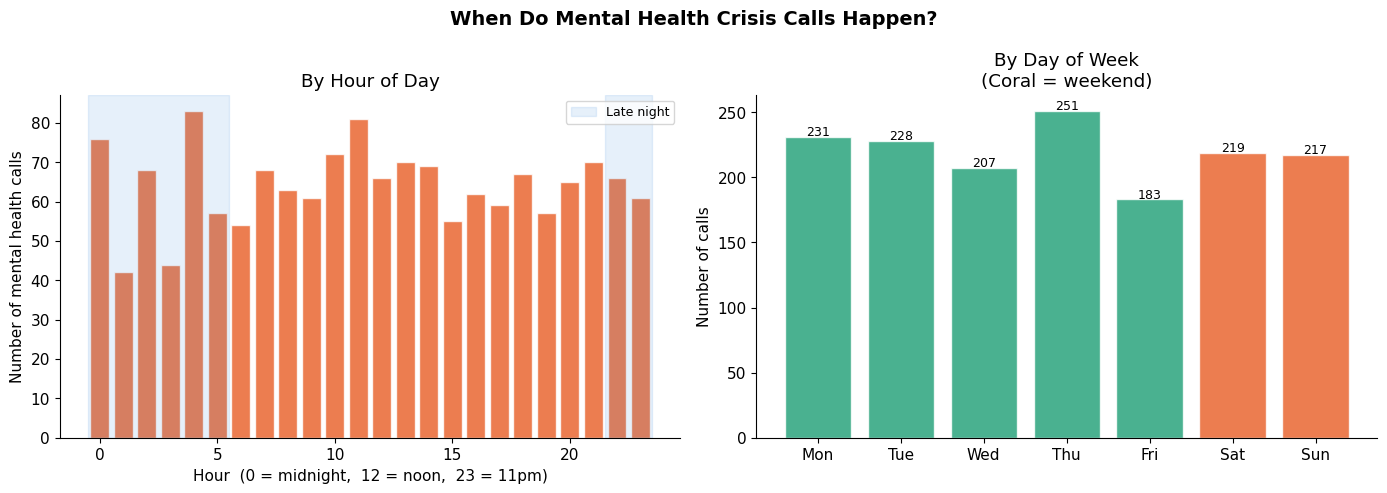

In [13]:
# Mental health crises don't happen randomly throughout the day
# Understanding WHEN they peak tells us when crisis centres need more staff

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("When Do Mental Health Crisis Calls Happen?",
             fontsize=14, fontweight="bold")

# ── LEFT: By hour of day ─────────────────────────────────────
hourly = mh_calls["hour"].value_counts().sort_index()

axes[0].bar(hourly.index, hourly.values, color=CORAL, alpha=0.8, edgecolor="white")
axes[0].set_title("By Hour of Day")
axes[0].set_xlabel("Hour  (0 = midnight,  12 = noon,  23 = 11pm)")
axes[0].set_ylabel("Number of mental health calls")

# Shade the late night period in light blue
axes[0].axvspan(21.5, 23.5, alpha=0.12, color=BLUE, label="Late night")
axes[0].axvspan(-0.5, 5.5,  alpha=0.12, color=BLUE)
axes[0].legend(fontsize=9)

# ── RIGHT: By day of week ─────────────────────────────────────
day_counts = mh_calls["day_of_week"].value_counts().sort_index()
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Weekends get coral colour, weekdays get teal
colors = [CORAL if i >= 5 else TEAL for i in range(7)]

bars = axes[1].bar(day_labels, day_counts.values,
                   color=colors, alpha=0.8, edgecolor="white")
axes[1].set_title("By Day of Week\n(Coral = weekend)")
axes[1].set_ylabel("Number of calls")

# Add the count number on top of each bar
for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{bar.get_height():,.0f}",
        ha="center", fontsize=9
    )

plt.tight_layout()
plt.show()

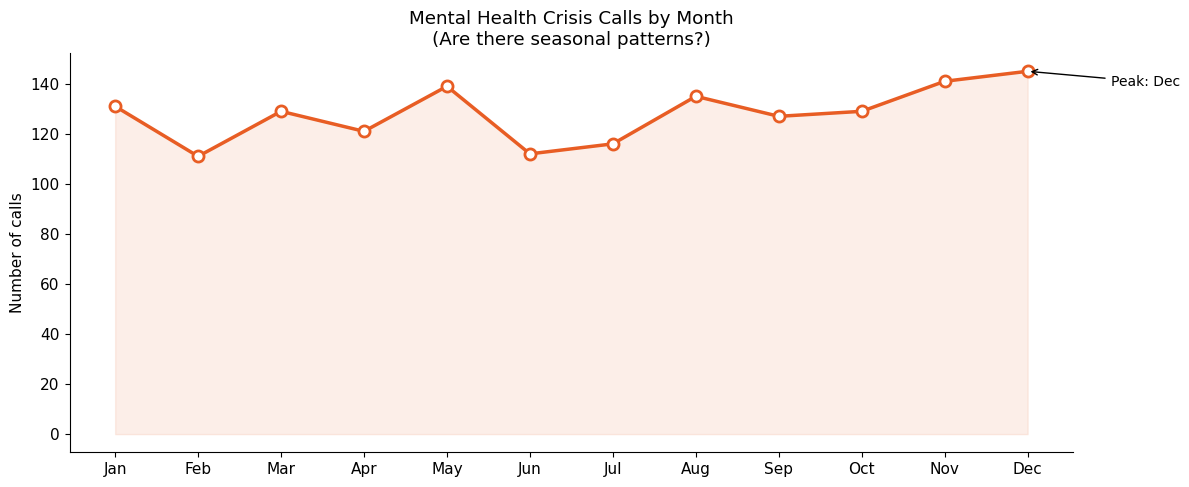

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

monthly      = mh_calls["month"].value_counts().sort_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# Line chart with a filled area underneath
ax.plot(range(12), monthly.values,
        color=CORAL, marker="o", linewidth=2.5,
        markersize=8, markerfacecolor="white", markeredgewidth=2)

# fill_between fills the area between the line and the x-axis
ax.fill_between(range(12), monthly.values, alpha=0.1, color=CORAL)

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)
ax.set_title("Mental Health Crisis Calls by Month\n"
             "(Are there seasonal patterns?)")
ax.set_ylabel("Number of calls")

# Find and label the peak month automatically
peak_idx = monthly.values.argmax()
ax.annotate(
    f"Peak: {month_labels[peak_idx]}",
    xy=(peak_idx, monthly.values[peak_idx]),
    xytext=(peak_idx + 1, monthly.values[peak_idx] * 0.96),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.tight_layout()
plt.show()

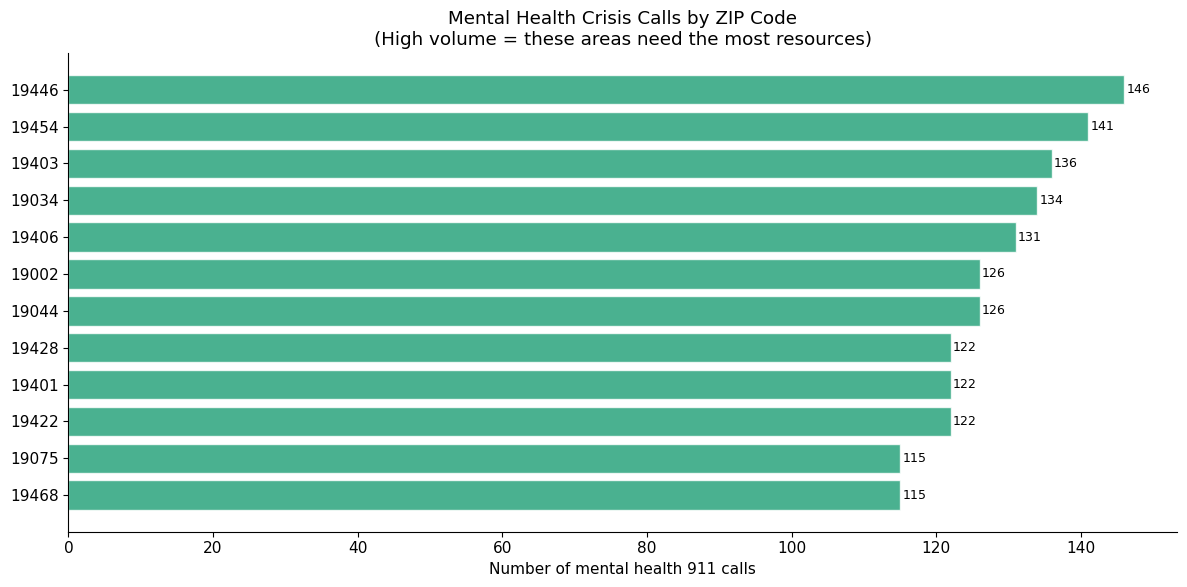

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# Count how many MH calls came from each ZIP code
zip_counts = mh_calls["zip"].value_counts().head(12)

# [::-1] reverses the order so the highest bar is at the TOP of a horizontal chart
bars = ax.barh(
    zip_counts.index.astype(str)[::-1],
    zip_counts.values[::-1],
    color=TEAL, alpha=0.8, edgecolor="white"
)

ax.set_title("Mental Health Crisis Calls by ZIP Code\n"
             "(High volume = these areas need the most resources)")
ax.set_xlabel("Number of mental health 911 calls")

# Add count labels on the right of each bar
for bar in bars:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():,.0f}",
        va="center", fontsize=9
    )

plt.tight_layout()
plt.show()

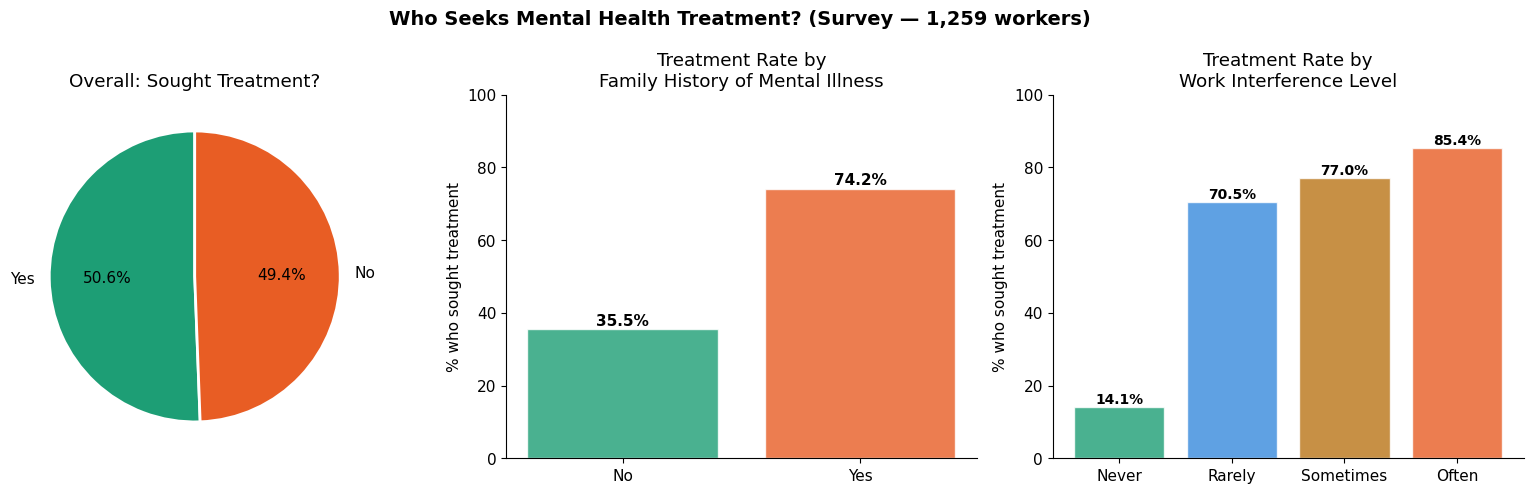

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Who Seeks Mental Health Treatment? (Survey — 1,259 workers)",
             fontsize=14, fontweight="bold")

# ── LEFT: Overall treatment rate ─────────────────────────────
treatment_counts = survey_df["treatment"].value_counts()
axes[0].pie(
    treatment_counts.values,
    labels=treatment_counts.index,
    autopct="%1.1f%%",
    colors=[TEAL, CORAL],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Overall: Sought Treatment?")

# ── MIDDLE: Treatment rate by family history ──────────────────
fam_treatment = survey_df.groupby("family_history")["treatment"].apply(
    lambda x: (x == "Yes").mean() * 100
).sort_values()

bars = axes[1].bar(
    fam_treatment.index,
    fam_treatment.values,
    color=[TEAL, CORAL], alpha=0.8, edgecolor="white"
)
for bar, val in zip(bars, fam_treatment.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center", fontsize=11, fontweight="bold"
    )
axes[1].set_title("Treatment Rate by\nFamily History of Mental Illness")
axes[1].set_ylabel("% who sought treatment")
axes[1].set_ylim(0, 100)

# ── RIGHT: Treatment rate by work interference ────────────────
# Only use rows where work_interfere is not missing
order = ["Never", "Rarely", "Sometimes", "Often"]
work_treatment = {}
for level in order:
    subset = survey_df[survey_df["work_interfere"] == level]["treatment"]
    if len(subset) > 0:
        work_treatment[level] = (subset == "Yes").mean() * 100

bar_colors = [TEAL, BLUE, AMBER, CORAL]
bars2 = axes[2].bar(
    list(work_treatment.keys()),
    list(work_treatment.values()),
    color=bar_colors[:len(work_treatment)],
    alpha=0.8, edgecolor="white"
)
for bar, val in zip(bars2, work_treatment.values()):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.1f}%",
        ha="center", fontsize=10, fontweight="bold"
    )
axes[2].set_title("Treatment Rate by\nWork Interference Level")
axes[2].set_ylabel("% who sought treatment")
axes[2].set_ylim(0, 100)

plt.tight_layout()
plt.show()


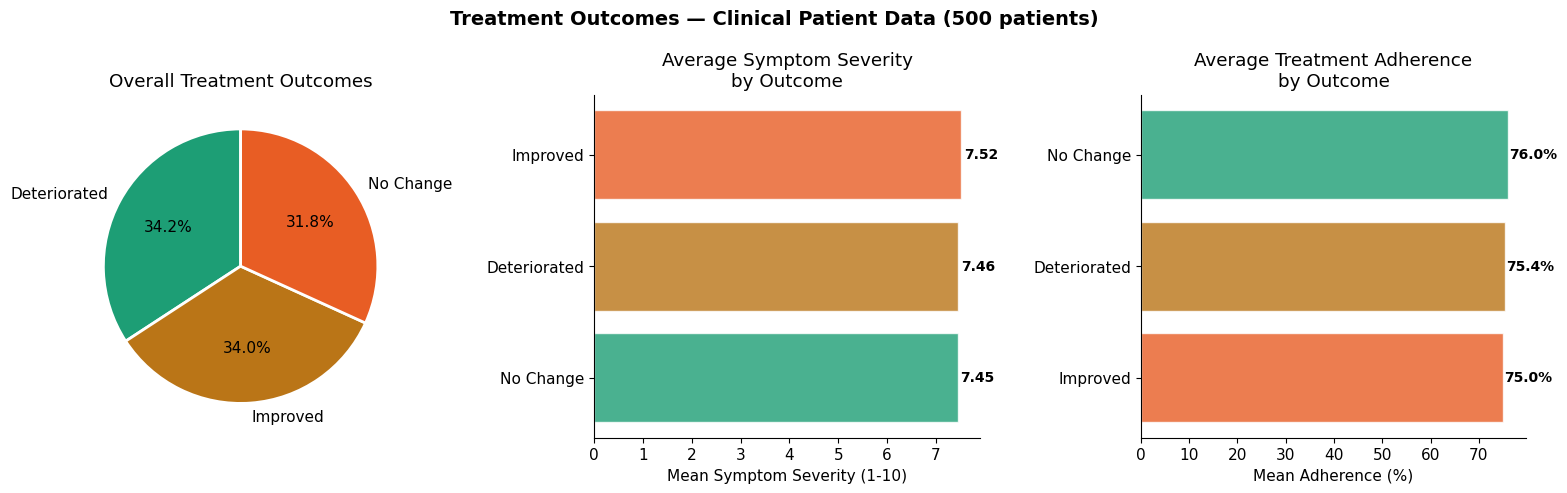

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Treatment Outcomes — Clinical Patient Data (500 patients)",
             fontsize=14, fontweight="bold")

# ── LEFT: Outcome distribution ────────────────────────────────
outcome_counts = treatment_df["Outcome"].value_counts()
colors_pie = [TEAL, AMBER, CORAL]
axes[0].pie(
    outcome_counts.values,
    labels=outcome_counts.index,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Overall Treatment Outcomes")

# ── MIDDLE: Symptom severity by outcome ───────────────────────
# groupby groups rows by Outcome, then we calculate the mean severity for each group
sev_by_outcome = treatment_df.groupby("Outcome")["Symptom Severity (1-10)"].mean().sort_values()

bars = axes[1].barh(
    sev_by_outcome.index,
    sev_by_outcome.values,
    color=[TEAL, AMBER, CORAL], alpha=0.8, edgecolor="white"
)
for bar, val in zip(bars, sev_by_outcome.values):
    axes[1].text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center", fontsize=10, fontweight="bold"
    )
axes[1].set_title("Average Symptom Severity\nby Outcome")
axes[1].set_xlabel("Mean Symptom Severity (1-10)")

# ── RIGHT: Adherence rate by outcome ─────────────────────────
adh_by_outcome = treatment_df.groupby("Outcome")["Adherence to Treatment (%)"].mean().sort_values()

bars2 = axes[2].barh(
    adh_by_outcome.index,
    adh_by_outcome.values,
    color=[CORAL, AMBER, TEAL], alpha=0.8, edgecolor="white"
)
for bar, val in zip(bars2, adh_by_outcome.values):
    axes[2].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", fontsize=10, fontweight="bold"
    )
axes[2].set_title("Average Treatment Adherence\nby Outcome")
axes[2].set_xlabel("Mean Adherence (%)")

plt.tight_layout()
plt.show()

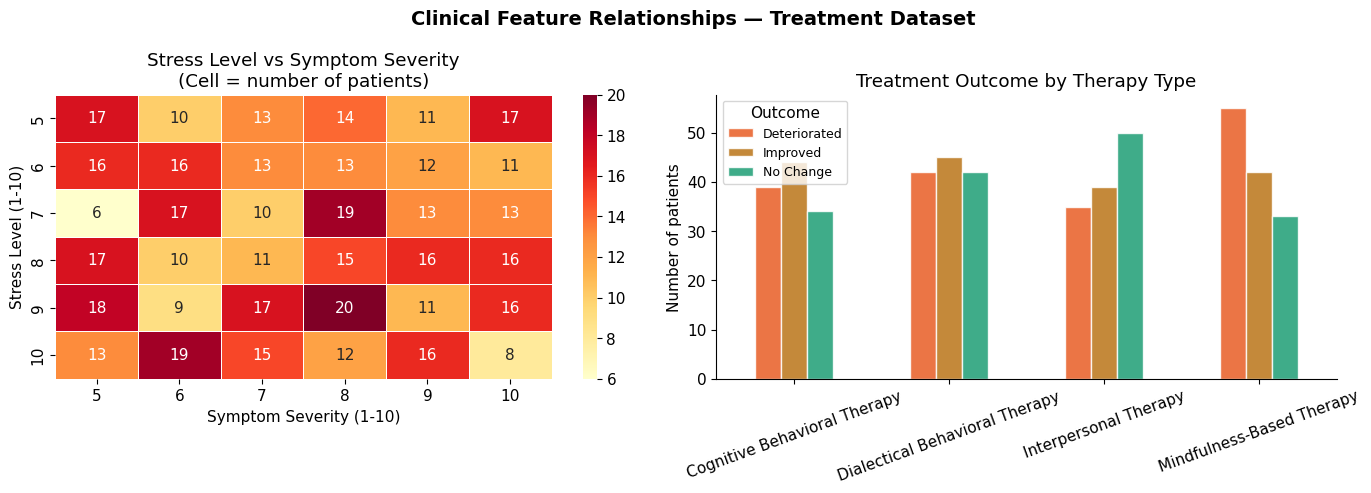

In [18]:
# This shows the relationship between stress and symptom severity
# A heatmap shows where patients cluster — dark cells = many patients

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Clinical Feature Relationships — Treatment Dataset",
             fontsize=14, fontweight="bold")

# ── LEFT: Stress vs Symptom Severity ─────────────────────────
pivot = treatment_df.pivot_table(
    index="Stress Level (1-10)",
    columns="Symptom Severity (1-10)",
    values="Patient ID",
    aggfunc="count"
)

sns.heatmap(
    pivot,
    cmap="YlOrRd",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Stress Level vs Symptom Severity\n(Cell = number of patients)")

# ── RIGHT: Therapy type vs outcome ────────────────────────────
therapy_outcome = treatment_df.groupby(
    ["Therapy Type", "Outcome"]
).size().unstack(fill_value=0)

therapy_outcome.plot(
    kind="bar",
    ax=axes[1],
    color=[CORAL, AMBER, TEAL],
    alpha=0.85,
    edgecolor="white"
)
axes[1].set_title("Treatment Outcome by Therapy Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of patients")
axes[1].legend(title="Outcome", fontsize=9)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

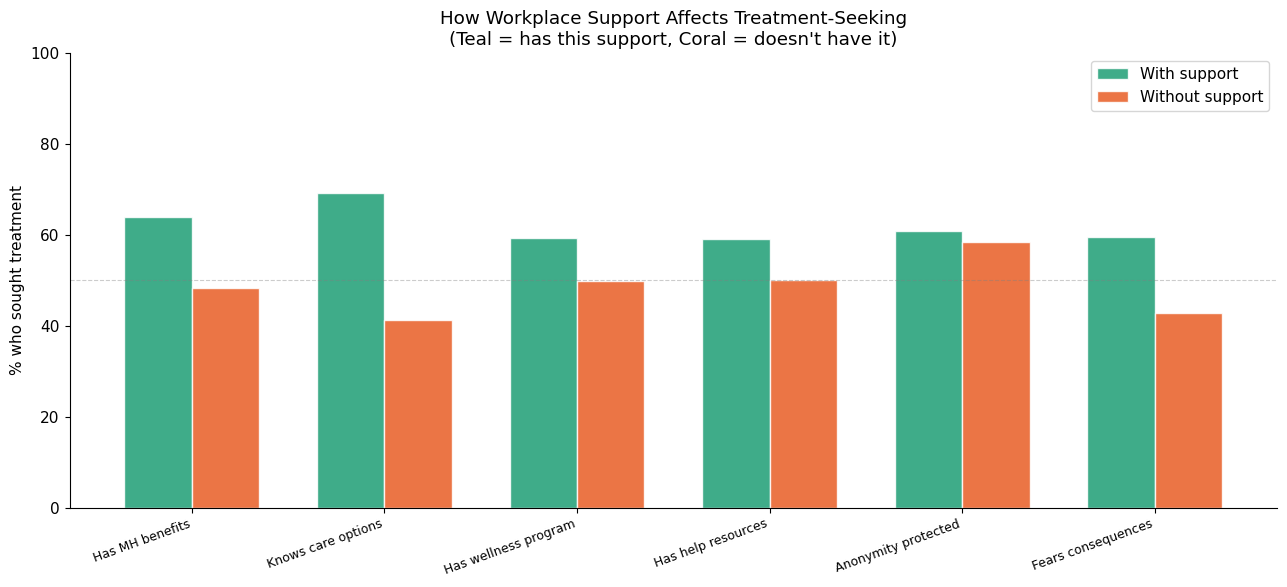

In [19]:
barrier_cols = {
    "benefits"                 : "Has MH benefits",
    "care_options"             : "Knows care options",
    "wellness_program"         : "Has wellness program",
    "seek_help"                : "Has help resources",
    "anonymity"                : "Anonymity protected",
    "mental_health_consequence": "Fears consequences"
}

fig, ax = plt.subplots(figsize=(13, 6))

with_support    = []
without_support = []
labels          = []

for col, label in barrier_cols.items():
    if col not in survey_df.columns:
        continue

    yes_mask = survey_df[col].isin(["Yes", "yes"])
    no_mask  = survey_df[col].isin(["No", "no"])

    yes_rate = (survey_df[yes_mask]["treatment"] == "Yes").mean() * 100
    no_rate  = (survey_df[no_mask]["treatment"]  == "Yes").mean() * 100

    with_support.append(yes_rate)
    without_support.append(no_rate)
    labels.append(label)

x     = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, with_support,    width,
               label="With support",    color=TEAL,  alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, without_support, width,
               label="Without support", color=CORAL, alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("% who sought treatment")
ax.set_title("How Workplace Support Affects Treatment-Seeking\n"
             "(Teal = has this support, Coral = doesn't have it)")
ax.legend()
ax.set_ylim(0, 100)
ax.axhline(50, color="gray", linestyle="--", alpha=0.4, linewidth=0.8)

plt.tight_layout()
plt.show()

In [20]:
# The Gender column has many variations of the same thing:
# "Male", "male", "M", "m", "MALE" all mean the same thing
# We standardise them all to just "Male", "Female", or "Other"

def clean_gender(gender_text):
    """
    Converts any gender text to Male, Female, or Other.
    """
    if pd.isnull(gender_text):
        return "Other"
    g = str(gender_text).strip().lower()

    # All the ways "male" appears in this dataset
    if g in ["male", "m", "man", "cis male", "male (cis)", "mail",
             "malr", "cis man", "maile", "msle", "make", "mal"]:
        return "Male"

    # All the ways "female" appears
    if g in ["female", "f", "woman", "cis female", "femake",
             "female (cis)", "cis-female/femme", "femail", "femaile"]:
        return "Female"

    return "Other"

survey_df["Gender_clean"] = survey_df["Gender"].apply(clean_gender)

print("Gender distribution after cleaning:")
print(survey_df["Gender_clean"].value_counts().to_string())

Gender distribution after cleaning:
Gender_clean
Male      990
Female    247
Other      22


In [21]:
# Some survey respondents entered unrealistic ages (e.g. -1, 999, 5)
# We keep only ages between 18 and 75 — the realistic working-age range

print(f"Age before cleaning: min={survey_df['Age'].min()}, max={survey_df['Age'].max()}")
print(f"Rows with unrealistic ages: {((survey_df['Age'] < 18) | (survey_df['Age'] > 75)).sum()}")

# Replace unrealistic ages with the median age
median_age = survey_df[(survey_df["Age"] >= 18) & (survey_df["Age"] <= 75)]["Age"].median()

survey_df.loc[survey_df["Age"] < 18, "Age"] = median_age
survey_df.loc[survey_df["Age"] > 75, "Age"] = median_age

print(f"Age after cleaning : min={survey_df['Age'].min()}, max={survey_df['Age'].max()}")
print(f"Median age         : {median_age:.0f}")

Age before cleaning: min=-1726, max=99999999999
Rows with unrealistic ages: 8
Age after cleaning : min=18, max=72
Median age         : 31


In [22]:
# work_interfere has 264 missing values (people who didn't answer)
# We fill with "Never" — the most conservative assumption
# (if they didn't report interference, it probably doesn't affect them)

print(f"Missing work_interfere before: {survey_df['work_interfere'].isnull().sum()}")
survey_df["work_interfere"].fillna("Never", inplace=True)
print(f"Missing work_interfere after : {survey_df['work_interfere'].isnull().sum()}")

Missing work_interfere before: 264
Missing work_interfere after : 0


In [23]:
# This is one of the most important cells in the project
# We CREATE our target variable — crisis severity
# by analysing keywords in the call title
#
# 0 = Low severity    (welfare check, general concern)
# 1 = Medium severity (active mental health crisis — needs clinician)
# 2 = High severity   (immediate danger — violent, suicidal with weapon)

def assign_severity(title_text):
    """
    Assigns 0 (low), 1 (medium), or 2 (high) based on call keywords.
    """
    if pd.isnull(title_text):
        return 0
    text = str(title_text).lower()

    # HIGH: immediate danger to life
    if any(kw in text for kw in ["suicid", "armed", "violent",
                                   "overdose", "harm", "threat"]):
        return 2

    # MEDIUM: active mental health crisis needing in-person response
    if any(kw in text for kw in ["mental", "psychiatric", "behavioral",
                                   "crisis", "erratic", "hallucin",
                                   "altered", "welfare"]):
        return 1

    return 0   # LOW: general or unspecified

mh_calls["crisis_severity"] = mh_calls["title"].apply(assign_severity)

print("Crisis severity distribution:")
sev_labels = {0: "Low    ", 1: "Medium ", 2: "High   "}
for level, count in mh_calls["crisis_severity"].value_counts().sort_index().items():
    pct = count / len(mh_calls) * 100
    bar = "█" * int(pct)
    print(f"  {sev_labels[level]} ({level}): {count:,} ({pct:.1f}%)  {bar}")

Crisis severity distribution:
  Medium  (1): 1,034 (67.3%)  ███████████████████████████████████████████████████████████████████
  High    (2): 502 (32.7%)  ████████████████████████████████


In [24]:
# Second target variable: who should respond to this call?
#
# 0 = Clinician only  → mental health professional, no police needed
# 1 = Police only     → safety issue, no mental health component
# 2 = Co-response     → both police AND clinician needed

def assign_responder(row):
    severity = row["crisis_severity"]
    title    = str(row["title"]).lower()

    if severity == 2:
        return 2   # HIGH severity → Co-response (police + clinician)
    elif severity == 1:
        return 0   # MEDIUM → Clinician only
    else:
        return 0   # LOW → Clinician only (de-escalation)

mh_calls["responder_type"] = mh_calls.apply(assign_responder, axis=1)

# Add realistic police-only calls for low severity cases
# (~20% of low severity calls are actually safety-first situations)
np.random.seed(42)
low_mask = mh_calls["crisis_severity"] == 0
mh_calls.loc[low_mask, "responder_type"] = np.random.choice(
    [0, 1], size=low_mask.sum(), p=[0.80, 0.20]
)

print("Responder type distribution:")
resp_labels = {0: "Clinician only", 1: "Police only   ", 2: "Co-response   "}
for rtype, count in mh_calls["responder_type"].value_counts().sort_index().items():
    pct = count / len(mh_calls) * 100
    print(f"  {resp_labels[rtype]} ({rtype}): {count:,} ({pct:.1f}%)")

Responder type distribution:
  Clinician only (0): 1,034 (67.3%)
  Co-response    (2): 502 (32.7%)


In [25]:
# Time features are strong predictors
# A crisis call at 3am on a Sunday is very different from 10am on a Tuesday

# Is it nighttime? (10pm to 6am)
mh_calls["is_night"] = ((mh_calls["hour"] >= 22) | (mh_calls["hour"] <= 6)).astype(int)

# Time of day category
def hour_to_period(hour):
    if   6  <= hour < 12:  return 0   # Morning
    elif 12 <= hour < 17:  return 1   # Afternoon
    elif 17 <= hour < 22:  return 2   # Evening
    else:                  return 3   # Night

mh_calls["time_period"] = mh_calls["hour"].apply(hour_to_period)

# Winter months (Dec, Jan, Feb) — higher depression and crisis rates
mh_calls["is_winter"] = mh_calls["month"].isin([12, 1, 2]).astype(int)

# Rush hour (7–9am and 5–7pm) — high-stress commuting periods
mh_calls["is_rush_hour"] = (
    ((mh_calls["hour"] >= 7)  & (mh_calls["hour"] <= 9)) |
    ((mh_calls["hour"] >= 17) & (mh_calls["hour"] <= 19))
).astype(int)

print("Time features created:")
print(f"  is_night     : {mh_calls['is_night'].sum():,} calls ({mh_calls['is_night'].mean()*100:.1f}%)")
print(f"  is_weekend   : {mh_calls['is_weekend'].sum():,} calls ({mh_calls['is_weekend'].mean()*100:.1f}%)")
print(f"  is_winter    : {mh_calls['is_winter'].sum():,} calls ({mh_calls['is_winter'].mean()*100:.1f}%)")
print(f"  is_rush_hour : {mh_calls['is_rush_hour'].sum():,} calls ({mh_calls['is_rush_hour'].mean()*100:.1f}%)")

Time features created:
  is_night     : 551 calls (35.9%)
  is_weekend   : 436 calls (28.4%)
  is_winter    : 387 calls (25.2%)
  is_rush_hour : 375 calls (24.4%)


In [26]:
# For each ZIP code we calculate:
# 1. How many total MH calls came from there
# 2. What fraction of those were high severity
# 3. A priority score = volume × severity rate
# This tells us WHICH AREAS need the most mental health resources

zip_stats = mh_calls.groupby("zip").agg(
    total_calls         = ("crisis_severity", "count"),
    high_severity_calls = ("crisis_severity", lambda x: (x == 2).sum()),
    avg_severity        = ("crisis_severity", "mean")
).reset_index()

zip_stats["high_severity_rate"] = (
    zip_stats["high_severity_calls"] / zip_stats["total_calls"]
)

# Priority score: areas with both high volume AND high severity need most help
zip_stats["priority_score"] = (
    zip_stats["total_calls"] * zip_stats["high_severity_rate"]
)

# Scale to 0–100 so it is easy to read
max_score = zip_stats["priority_score"].max()
zip_stats["priority_score_scaled"] = (
    zip_stats["priority_score"] / max_score * 100
).round(1)

# Merge these ZIP-level features back into the main calls dataframe
mh_calls = mh_calls.merge(
    zip_stats[["zip", "high_severity_rate", "priority_score_scaled"]],
    on="zip", how="left"
)
mh_calls["high_severity_rate"]    = mh_calls["high_severity_rate"].fillna(0)
mh_calls["priority_score_scaled"] = mh_calls["priority_score_scaled"].fillna(0)

print("Top 10 highest priority ZIP codes:")
print(zip_stats.nlargest(10, "priority_score_scaled")[
    ["zip", "total_calls", "high_severity_calls",
     "high_severity_rate", "priority_score_scaled"]
].to_string(index=False))

Top 10 highest priority ZIP codes:
  zip  total_calls  high_severity_calls  high_severity_rate  priority_score_scaled
19446          146                   56            0.383562                  100.0
19403          136                   51            0.375000                   91.1
19454          141                   51            0.361702                   91.1
19044          126                   43            0.341270                   76.8
19406          131                   42            0.320611                   75.0
19002          126                   41            0.325397                   73.2
19428          122                   41            0.336066                   73.2
19075          115                   39            0.339130                   69.6
19468          115                   37            0.321739                   66.1
19401          122                   36            0.295082                   64.3


In [27]:
# From the treatment dataset we can calculate a "clinical risk score"
# for each patient using their symptom severity, stress level, and mood
# This enriches our understanding of what makes a crisis severe

# Encode the Outcome column as a number
# Improved = 0, No Change = 1, Deteriorated = 2
outcome_map = {"Improved": 0, "No Change": 1, "Deteriorated": 2}
treatment_df["outcome_encoded"] = treatment_df["Outcome"].map(outcome_map)

# Clinical risk score = average of normalised symptom severity + stress
# Both are already on 1-10 scale so we average them directly
treatment_df["clinical_risk_score"] = (
    treatment_df["Symptom Severity (1-10)"] +
    treatment_df["Stress Level (1-10)"]
) / 2

print("Clinical risk score statistics:")
print(f"  Mean   : {treatment_df['clinical_risk_score'].mean():.2f}")
print(f"  Min    : {treatment_df['clinical_risk_score'].min():.2f}")
print(f"  Max    : {treatment_df['clinical_risk_score'].max():.2f}")

# Average clinical risk score by outcome — confirms the feature makes sense
print("\nAverage clinical risk score by treatment outcome:")
print(treatment_df.groupby("Outcome")["clinical_risk_score"].mean().round(2).to_string())
print("\n(Higher risk score for Deteriorated patients = feature is meaningful)")

Clinical risk score statistics:
  Mean   : 7.51
  Min    : 5.00
  Max    : 10.00

Average clinical risk score by treatment outcome:
Outcome
Deteriorated    7.53
Improved        7.54
No Change       7.46

(Higher risk score for Deteriorated patients = feature is meaningful)


In [28]:
import os

os.makedirs("outputs/processed", exist_ok=True)
os.makedirs("outputs/models",    exist_ok=True)
os.makedirs("outputs/evaluation",exist_ok=True)

# ── DATASET 1: 911 crisis calls model dataset ─────────────────
# Features we keep for modelling
call_feature_cols = [
    "hour", "day_of_week", "month",
    "is_weekend", "is_night", "time_period",
    "is_winter", "is_rush_hour",
    "high_severity_rate", "priority_score_scaled"
]

calls_model_df = mh_calls[call_feature_cols +
                           ["crisis_severity", "responder_type"]].copy()
calls_model_df = calls_model_df.dropna()
calls_model_df.to_csv("outputs/processed/crisis_features_final.csv", index=False)

# ── DATASET 2: Treatment outcome model dataset ────────────────
treat_feature_cols = [
    "Age", "Symptom Severity (1-10)", "Mood Score (1-10)",
    "Sleep Quality (1-10)", "Physical Activity (hrs/week)",
    "Treatment Duration (weeks)", "Stress Level (1-10)",
    "Treatment Progress (1-10)", "Adherence to Treatment (%)",
    "clinical_risk_score"
]

# One-hot encode Diagnosis and Therapy Type
diagnosis_dummies   = pd.get_dummies(treatment_df["Diagnosis"],   prefix="diag")
therapy_dummies     = pd.get_dummies(treatment_df["Therapy Type"], prefix="therapy")
gender_dummies      = pd.get_dummies(treatment_df["Gender"],       prefix="gender")

treat_model_df = pd.concat(
    [treatment_df[treat_feature_cols],
     diagnosis_dummies, therapy_dummies, gender_dummies,
     treatment_df["outcome_encoded"]],
    axis=1
)
treat_model_df.to_csv("outputs/processed/treatment_features_final.csv", index=False)

# ── DATASET 3: Survey treatment-seeking model dataset ─────────
# Encode categorical survey columns as numbers

survey_encode = survey_df.copy()

# Binary columns: Yes=1, No=0
binary_cols = ["family_history", "treatment", "remote_work",
               "tech_company", "self_employed", "obs_consequence"]
for col in binary_cols:
    if col in survey_encode.columns:
        survey_encode[col] = (survey_encode[col] == "Yes").astype(int)

# Ordinal: work interference level
wi_map = {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3}
survey_encode["work_interfere_num"] = survey_encode["work_interfere"].map(wi_map).fillna(0)

# One-hot encode company size and gender
size_dummies   = pd.get_dummies(survey_encode["no_employees"], prefix="size")
gender_dummies2 = pd.get_dummies(survey_encode["Gender_clean"], prefix="gender")

survey_feature_cols = ["Age", "family_history", "work_interfere_num",
                        "remote_work", "self_employed", "obs_consequence"]
survey_model_df = pd.concat(
    [survey_encode[survey_feature_cols],
     size_dummies, gender_dummies2,
     survey_encode["treatment"]],
    axis=1
)
survey_model_df = survey_model_df.dropna()
survey_model_df.to_csv("outputs/processed/survey_features_final.csv", index=False)

print("✓ All 3 processed datasets saved:")
print(f"  crisis_features_final.csv   : {calls_model_df.shape}")
print(f"  treatment_features_final.csv: {treat_model_df.shape}")
print(f"  survey_features_final.csv   : {survey_model_df.shape}")

✓ All 3 processed datasets saved:
  crisis_features_final.csv   : (1536, 12)
  treatment_features_final.csv: (500, 21)
  survey_features_final.csv   : (1259, 16)


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
import pickle

# ── Load all 3 processed datasets ────────────────────────────
calls_m    = pd.read_csv("outputs/processed/crisis_features_final.csv")
treatment_m = pd.read_csv("outputs/processed/treatment_features_final.csv")
survey_m   = pd.read_csv("outputs/processed/survey_features_final.csv")

# ── SPLIT 1: Crisis severity model ───────────────────────────
call_feat_cols = [c for c in calls_m.columns
                  if c not in ["crisis_severity", "responder_type"]]

X_call = calls_m[call_feat_cols]
y_sev  = calls_m["crisis_severity"]
y_resp = calls_m["responder_type"]

X_call_train, X_call_test, ys_train, ys_test = train_test_split(
    X_call, y_sev, test_size=0.2, random_state=42, stratify=y_sev
)
_, _, yr_train, yr_test = train_test_split(
    X_call, y_resp, test_size=0.2, random_state=42, stratify=y_resp
)

# ── SPLIT 2: Treatment outcome model ─────────────────────────
treat_feat_cols = [c for c in treatment_m.columns if c != "outcome_encoded"]
X_treat = treatment_m[treat_feat_cols]
y_treat = treatment_m["outcome_encoded"]

X_tr_train, X_tr_test, yt_train, yt_test = train_test_split(
    X_treat, y_treat, test_size=0.2, random_state=42, stratify=y_treat
)

# ── SPLIT 3: Survey treatment-seeking model ───────────────────
surv_feat_cols = [c for c in survey_m.columns if c != "treatment"]
X_surv = survey_m[surv_feat_cols]
y_surv = survey_m["treatment"]

X_sv_train, X_sv_test, yv_train, yv_test = train_test_split(
    X_surv, y_surv, test_size=0.2, random_state=42, stratify=y_surv
)

# ── Scale all datasets ────────────────────────────────────────
scalers = {}
scaled_data = {}

for name, X_train, X_test in [
    ("call",    X_call_train, X_call_test),
    ("treat",   X_tr_train,   X_tr_test),
    ("survey",  X_sv_train,   X_sv_test)
]:
    sc = StandardScaler()
    Xtr_sc = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
    Xte_sc = pd.DataFrame(sc.transform(X_test),      columns=X_train.columns)
    scalers[name]      = sc
    scaled_data[name]  = (Xtr_sc, Xte_sc)

    with open(f"outputs/models/scaler_{name}.pkl", "wb") as f:
        pickle.dump(sc, f)

print("All datasets split and scaled:")
print(f"  Crisis calls  : {X_call_train.shape[0]:,} train / {X_call_test.shape[0]:,} test")
print(f"  Treatment     : {X_tr_train.shape[0]:,} train / {X_tr_test.shape[0]:,} test")
print(f"  Survey        : {X_sv_train.shape[0]:,} train / {X_sv_test.shape[0]:,} test")
print("✓ Scalers saved")

All datasets split and scaled:
  Crisis calls  : 1,228 train / 308 test
  Treatment     : 400 train / 100 test
  Survey        : 1,007 train / 252 test
✓ Scalers saved


In [30]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report, roc_auc_score)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not installed — run: pip install xgboost")

RANDOM_STATE = 42
cv           = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def get_models():
    """Returns a fresh dictionary of models — call this every time you need new instances."""
    m = {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE,
            class_weight="balanced", multi_class="multinomial"
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, random_state=RANDOM_STATE,
            class_weight="balanced", n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1,
            max_depth=4, random_state=RANDOM_STATE
        ),
        "MLP Neural Network": MLPClassifier(
            hidden_layer_sizes=(128, 64, 32),
            max_iter=500, random_state=RANDOM_STATE,
            early_stopping=True
        )
    }
    if XGBOOST_AVAILABLE:
        m["XGBoost"] = XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=5,
            random_state=RANDOM_STATE, eval_metric="mlogloss",
            verbosity=0, use_label_encoder=False
        )
    return m

print(f"Models ready: {list(get_models().keys())}")

✓ XGBoost available
Models ready: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'MLP Neural Network', 'XGBoost']


In [36]:
# Check what classes currently exist in each split
print("Classes in ys_train:", sorted(ys_train.unique()))
print("Classes in ys_test :", sorted(ys_test.unique()))

# Remap labels to guarantee 0, 1, 2
# This maps whatever the actual values are to 0, 1, 2 in sorted order
unique_classes = sorted(ys_train.unique())
label_map      = {old: new for new, old in enumerate(unique_classes)}

print(f"\nLabel mapping being applied: {label_map}")

ys_train = ys_train.map(label_map)
ys_test  = ys_test.map(label_map)

# Do the same for responder type
unique_resp = sorted(yr_train.unique())
resp_map    = {old: new for new, old in enumerate(unique_resp)}
yr_train    = yr_train.map(resp_map)
yr_test     = yr_test.map(resp_map)

print(f"\nAfter fix:")
print(f"  ys_train classes: {sorted(ys_train.unique())}")
print(f"  ys_test  classes: {sorted(ys_test.unique())}")
print(f"  yr_train classes: {sorted(yr_train.unique())}")
print(f"  yr_test  classes: {sorted(yr_test.unique())}")

Classes in ys_train: [np.int64(0), np.int64(1)]
Classes in ys_test : [np.int64(0), np.int64(1)]

Label mapping being applied: {np.int64(0): 0, np.int64(1): 1}

After fix:
  ys_train classes: [np.int64(0), np.int64(1)]
  ys_test  classes: [np.int64(0), np.int64(1)]
  yr_train classes: [np.int64(0), np.int64(1)]
  yr_test  classes: [np.int64(0), np.int64(1)]


In [37]:
print("=" * 58)
print("MODEL 1: CRISIS SEVERITY (0=Low  1=Medium  2=High)")
print("=" * 58)

Xtr_call, Xte_call = scaled_data["call"]
sev_results        = []

for name, model in get_models().items():
    print(f"\n  Training {name}...")
    model.fit(Xtr_call, ys_train)

    y_pred    = model.predict(Xte_call)
    acc       = accuracy_score(ys_test, y_pred)
    f1        = f1_score(ys_test, y_pred, average="weighted")
    cv_scores = cross_val_score(model, Xtr_call, ys_train,
                                cv=cv, scoring="f1_weighted", n_jobs=-1)

    sev_results.append({
        "Model"       : name,
        "Accuracy"    : round(acc, 4),
        "F1 Weighted" : round(f1, 4),
        "CV F1 Mean"  : round(cv_scores.mean(), 4),
        "CV F1 Std"   : round(cv_scores.std(), 4)
    })
    print(f"    Accuracy: {acc:.4f}  F1: {f1:.4f}  CV: {cv_scores.mean():.4f}")

    safe = name.lower().replace(" ", "_")
    with open(f"outputs/models/severity_{safe}.pkl", "wb") as f:
        pickle.dump(model, f)

sev_df = pd.DataFrame(sev_results).sort_values("F1 Weighted", ascending=False)
print("\n" + "=" * 58)
print(sev_df.to_string(index=False))

# Save the best model
best_sev_name = sev_df.iloc[0]["Model"]
safe = best_sev_name.lower().replace(" ", "_")
with open(f"outputs/models/severity_{safe}.pkl", "rb") as f:
    best_sev_model = pickle.load(f)
with open("outputs/models/best_severity_model.pkl", "wb") as f:
    pickle.dump(best_sev_model, f)
print(f"\n✓ Best Model 1: {best_sev_name}")

MODEL 1: CRISIS SEVERITY (0=Low  1=Medium  2=High)

  Training Logistic Regression...
    Accuracy: 0.4351  F1: 0.4511  CV: 0.5225

  Training Random Forest...
    Accuracy: 0.6461  F1: 0.6082  CV: 0.6017

  Training Gradient Boosting...
    Accuracy: 0.6136  F1: 0.5722  CV: 0.6021

  Training MLP Neural Network...
    Accuracy: 0.6721  F1: 0.5403  CV: 0.5439

  Training XGBoost...
    Accuracy: 0.5812  F1: 0.5442  CV: 0.6156

              Model  Accuracy  F1 Weighted  CV F1 Mean  CV F1 Std
      Random Forest    0.6461       0.6082      0.6017     0.0105
  Gradient Boosting    0.6136       0.5722      0.6021     0.0205
            XGBoost    0.5812       0.5442      0.6156     0.0178
 MLP Neural Network    0.6721       0.5403      0.5439     0.0021
Logistic Regression    0.4351       0.4511      0.5225     0.0328

✓ Best Model 1: Random Forest


In [38]:
print("=" * 58)
print("MODEL 2: TREATMENT OUTCOME (0=Improved  1=No Change  2=Deteriorated)")
print("=" * 58)

Xtr_treat, Xte_treat = scaled_data["treat"]
treat_results         = []

for name, model in get_models().items():
    print(f"\n  Training {name}...")
    model.fit(Xtr_treat, yt_train)

    y_pred    = model.predict(Xte_treat)
    acc       = accuracy_score(yt_test, y_pred)
    f1        = f1_score(yt_test, y_pred, average="weighted")
    cv_scores = cross_val_score(model, Xtr_treat, yt_train,
                                cv=cv, scoring="f1_weighted", n_jobs=-1)

    treat_results.append({
        "Model"       : name,
        "Accuracy"    : round(acc, 4),
        "F1 Weighted" : round(f1, 4),
        "CV F1 Mean"  : round(cv_scores.mean(), 4),
    })
    print(f"    Accuracy: {acc:.4f}  F1: {f1:.4f}  CV: {cv_scores.mean():.4f}")

    safe = name.lower().replace(" ", "_")
    with open(f"outputs/models/treatment_{safe}.pkl", "wb") as f:
        pickle.dump(model, f)

treat_df = pd.DataFrame(treat_results).sort_values("F1 Weighted", ascending=False)
print("\n" + "=" * 58)
print(treat_df.to_string(index=False))

best_treat_name = treat_df.iloc[0]["Model"]
safe = best_treat_name.lower().replace(" ", "_")
with open(f"outputs/models/treatment_{safe}.pkl", "rb") as f:
    best_treat_model = pickle.load(f)
with open("outputs/models/best_treatment_model.pkl", "wb") as f:
    pickle.dump(best_treat_model, f)
print(f"\n✓ Best Model 2: {best_treat_name}")

MODEL 2: TREATMENT OUTCOME (0=Improved  1=No Change  2=Deteriorated)

  Training Logistic Regression...
    Accuracy: 0.3100  F1: 0.3061  CV: 0.3371

  Training Random Forest...
    Accuracy: 0.3000  F1: 0.2974  CV: 0.3573

  Training Gradient Boosting...
    Accuracy: 0.2700  F1: 0.2607  CV: 0.3636

  Training MLP Neural Network...
    Accuracy: 0.3300  F1: 0.3101  CV: 0.3209

  Training XGBoost...
    Accuracy: 0.2900  F1: 0.2853  CV: 0.3723

              Model  Accuracy  F1 Weighted  CV F1 Mean
 MLP Neural Network      0.33       0.3101      0.3209
Logistic Regression      0.31       0.3061      0.3371
      Random Forest      0.30       0.2974      0.3573
            XGBoost      0.29       0.2853      0.3723
  Gradient Boosting      0.27       0.2607      0.3636

✓ Best Model 2: MLP Neural Network


In [39]:
print("=" * 58)
print("MODEL 3: WILL THIS PERSON SEEK TREATMENT? (0=No  1=Yes)")
print("=" * 58)

Xtr_surv, Xte_surv = scaled_data["survey"]
surv_results        = []

# This is binary classification — simpler than the multiclass models above
binary_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        class_weight="balanced", n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=4, random_state=RANDOM_STATE
    ),
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500,
        random_state=RANDOM_STATE, early_stopping=True
    )
}
if XGBOOST_AVAILABLE:
    binary_models["XGBoost"] = XGBClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5,
        random_state=RANDOM_STATE, eval_metric="logloss",
        verbosity=0, use_label_encoder=False
    )

for name, model in binary_models.items():
    print(f"\n  Training {name}...")
    model.fit(Xtr_surv, yv_train)

    y_pred    = model.predict(Xte_surv)
    y_prob    = model.predict_proba(Xte_surv)[:, 1]
    acc       = accuracy_score(yv_test, y_pred)
    f1        = f1_score(yv_test, y_pred, average="binary")
    auc       = roc_auc_score(yv_test, y_prob)
    cv_scores = cross_val_score(model, Xtr_surv, yv_train,
                                cv=cv, scoring="roc_auc", n_jobs=-1)

    surv_results.append({
        "Model"      : name,
        "Accuracy"   : round(acc, 4),
        "F1"         : round(f1,  4),
        "AUROC"      : round(auc, 4),
        "CV AUC Mean": round(cv_scores.mean(), 4),
    })
    print(f"    Accuracy: {acc:.4f}  F1: {f1:.4f}  AUROC: {auc:.4f}")

    safe = name.lower().replace(" ", "_")
    with open(f"outputs/models/survey_{safe}.pkl", "wb") as f:
        pickle.dump(model, f)

surv_df = pd.DataFrame(surv_results).sort_values("AUROC", ascending=False)
print("\n" + "=" * 55)
print(surv_df.to_string(index=False))

best_surv_name = surv_df.iloc[0]["Model"]
safe = best_surv_name.lower().replace(" ", "_")
with open(f"outputs/models/survey_{safe}.pkl", "rb") as f:
    best_surv_model = pickle.load(f)
with open("outputs/models/best_survey_model.pkl", "wb") as f:
    pickle.dump(best_surv_model, f)
print(f"\n✓ Best Model 3: {best_surv_name}")

MODEL 3: WILL THIS PERSON SEEK TREATMENT? (0=No  1=Yes)

  Training Logistic Regression...
    Accuracy: 0.8135  F1: 0.8226  AUROC: 0.8763

  Training Random Forest...
    Accuracy: 0.8016  F1: 0.8092  AUROC: 0.8415

  Training Gradient Boosting...
    Accuracy: 0.8016  F1: 0.8077  AUROC: 0.8478

  Training MLP Neural Network...
    Accuracy: 0.8056  F1: 0.8123  AUROC: 0.8647

  Training XGBoost...
    Accuracy: 0.8016  F1: 0.8077  AUROC: 0.8484

              Model  Accuracy     F1  AUROC  CV AUC Mean
Logistic Regression    0.8135 0.8226 0.8763       0.8808
 MLP Neural Network    0.8056 0.8123 0.8647       0.8615
            XGBoost    0.8016 0.8077 0.8484       0.8558
  Gradient Boosting    0.8016 0.8077 0.8478       0.8498
      Random Forest    0.8016 0.8092 0.8415       0.8510

✓ Best Model 3: Logistic Regression


Actual classes in ys_test  : [np.int64(0), np.int64(1)]
Actual classes in sev_pred : [np.int64(0), np.int64(1)]
Actual classes in yt_test  : [np.int64(0), np.int64(1), np.int64(2)]
Actual classes in yr_test  : [np.int64(0), np.int64(1)]
Actual classes in yv_test  : [np.int64(0), np.int64(1)]

Labels being used:
  Model 1 (severity) : ['Low', 'Medium']
  Model 2 (treatment): ['Improved', 'No Change', 'Deteriorated']
  Model 3 (survey)   : ["Won't seek", 'Will seek']


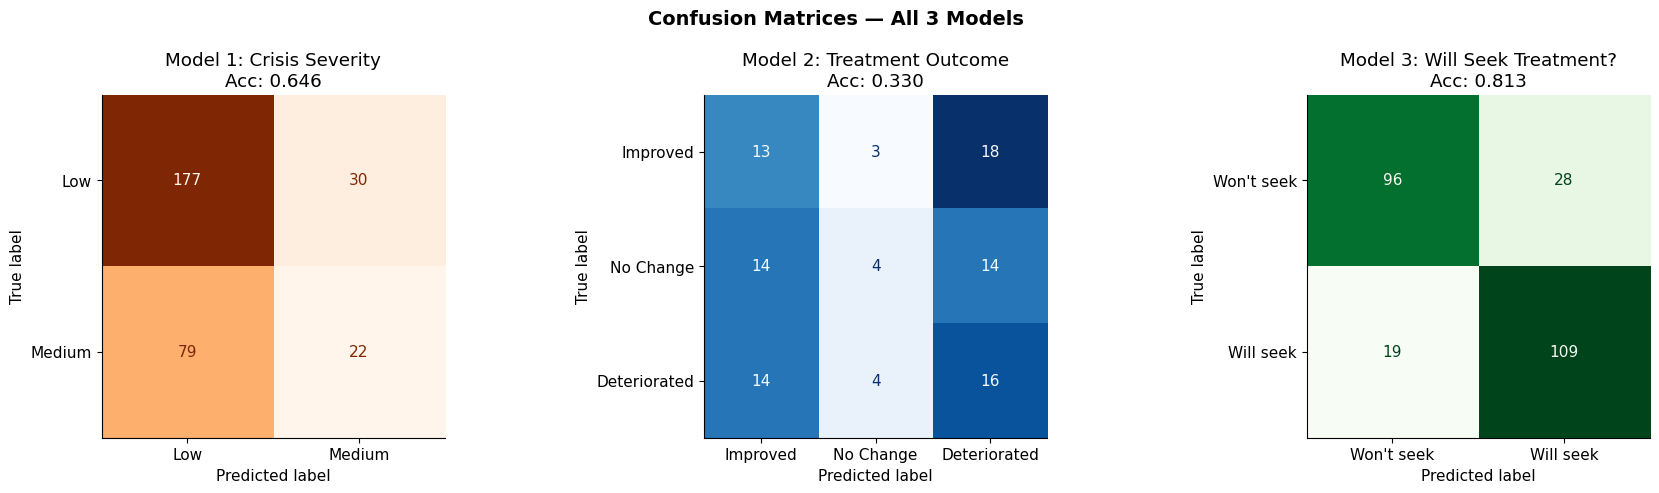

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reload best models
with open("outputs/models/best_severity_model.pkl",  "rb") as f:
    best_sev   = pickle.load(f)
with open("outputs/models/best_treatment_model.pkl", "rb") as f:
    best_treat = pickle.load(f)
with open("outputs/models/best_survey_model.pkl",    "rb") as f:
    best_surv  = pickle.load(f)

Xtr_call,  Xte_call  = scaled_data["call"]
Xtr_treat, Xte_treat = scaled_data["treat"]
Xtr_surv,  Xte_surv  = scaled_data["survey"]

# Generate predictions
sev_pred   = best_sev.predict(Xte_call)
treat_pred = best_treat.predict(Xte_treat)
surv_pred  = best_surv.predict(Xte_surv)

# Check what classes actually exist in each set of predictions
# This is what was causing the crash — we were assuming 3 classes existed
# but after remapping only 2 were present in the test split
print("Actual classes in ys_test  :", sorted(ys_test.unique()))
print("Actual classes in sev_pred :", sorted(set(sev_pred)))
print("Actual classes in yt_test  :", sorted(yt_test.unique()))
print("Actual classes in yr_test  :", sorted(yr_test.unique()))
print("Actual classes in yv_test  :", sorted(yv_test.unique()))

# Build labels dynamically based on what classes actually exist
# instead of hardcoding ["Low", "Medium", "High"]

sev_label_map   = {0: "Low", 1: "Medium", 2: "High"}
treat_label_map = {0: "Improved", 1: "No Change", 2: "Deteriorated"}
surv_label_map  = {0: "Won't seek", 1: "Will seek"}

# Get only the labels that actually appear in the test data
sev_labels   = [sev_label_map[c]   for c in sorted(ys_test.unique())]
treat_labels = [treat_label_map[c] for c in sorted(yt_test.unique())]
surv_labels  = [surv_label_map[c]  for c in sorted(yv_test.unique())]

print("\nLabels being used:")
print(f"  Model 1 (severity) : {sev_labels}")
print(f"  Model 2 (treatment): {treat_labels}")
print(f"  Model 3 (survey)   : {surv_labels}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All 3 Models", fontsize=14, fontweight="bold")

# Model 1 — use dynamic labels
ConfusionMatrixDisplay(
    confusion_matrix(ys_test, sev_pred),
    display_labels=sev_labels
).plot(ax=axes[0], cmap="Oranges", colorbar=False)
axes[0].set_title(f"Model 1: Crisis Severity\n"
                  f"Acc: {accuracy_score(ys_test, sev_pred):.3f}")

# Model 2 — use dynamic labels
ConfusionMatrixDisplay(
    confusion_matrix(yt_test, treat_pred),
    display_labels=treat_labels
).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Model 2: Treatment Outcome\n"
                  f"Acc: {accuracy_score(yt_test, treat_pred):.3f}")

# Model 3 — use dynamic labels
ConfusionMatrixDisplay(
    confusion_matrix(yv_test, surv_pred),
    display_labels=surv_labels
).plot(ax=axes[2], cmap="Greens", colorbar=False)
axes[2].set_title(f"Model 3: Will Seek Treatment?\n"
                  f"Acc: {accuracy_score(yv_test, surv_pred):.3f}")

plt.tight_layout()
plt.show()

In [44]:
# Build dynamic labels based on what classes actually exist
# This is the same approach that fixed the confusion matrix error

sev_label_map   = {0: "Low", 1: "Medium", 2: "High"}
treat_label_map = {0: "Improved", 1: "No Change", 2: "Deteriorated"}
surv_label_map  = {0: "Won't seek", 1: "Will seek"}

sev_labels   = [sev_label_map[c]   for c in sorted(ys_test.unique())]
treat_labels = [treat_label_map[c] for c in sorted(yt_test.unique())]
surv_labels  = [surv_label_map[c]  for c in sorted(yv_test.unique())]

print("=== MODEL 1: CRISIS SEVERITY ===")
print(f"Classes present in test set: {sev_labels}")
print(classification_report(
    ys_test, sev_pred,
    target_names=sev_labels
))

print("\n=== MODEL 2: TREATMENT OUTCOME ===")
print(f"Classes present in test set: {treat_labels}")
print(classification_report(
    yt_test, treat_pred,
    target_names=treat_labels
))

print("\n=== MODEL 3: TREATMENT SEEKING ===")
print(f"Classes present in test set: {surv_labels}")
print(classification_report(
    yv_test, surv_pred,
    target_names=surv_labels
))

=== MODEL 1: CRISIS SEVERITY ===
Classes present in test set: ['Low', 'Medium']
              precision    recall  f1-score   support

         Low       0.69      0.86      0.76       207
      Medium       0.42      0.22      0.29       101

    accuracy                           0.65       308
   macro avg       0.56      0.54      0.53       308
weighted avg       0.60      0.65      0.61       308


=== MODEL 2: TREATMENT OUTCOME ===
Classes present in test set: ['Improved', 'No Change', 'Deteriorated']
              precision    recall  f1-score   support

    Improved       0.32      0.38      0.35        34
   No Change       0.36      0.12      0.19        32
Deteriorated       0.33      0.47      0.39        34

    accuracy                           0.33       100
   macro avg       0.34      0.33      0.31       100
weighted avg       0.34      0.33      0.31       100


=== MODEL 3: TREATMENT SEEKING ===
Classes present in test set: ["Won't seek", 'Will seek']
            

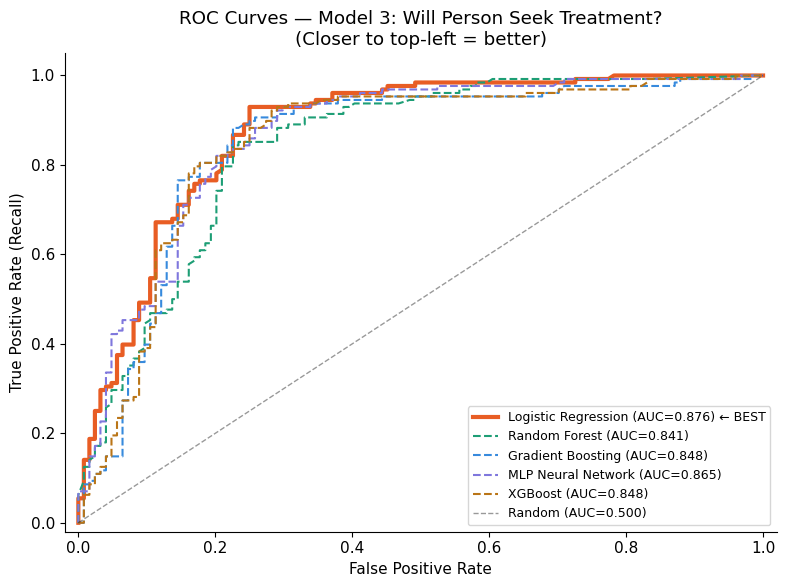

In [45]:
from sklearn.metrics import roc_curve, auc as auc_score

fig, ax = plt.subplots(figsize=(8, 6))

# Load all survey models to compare on the same chart
model_colors = {
    "Logistic Regression": CORAL,
    "Random Forest"      : TEAL,
    "Gradient Boosting"  : BLUE,
    "MLP Neural Network" : PURPLE,
    "XGBoost"            : AMBER
}

for name, color in model_colors.items():
    path = f"outputs/models/survey_{name.lower().replace(' ', '_')}.pkl"
    if not os.path.exists(path):
        continue
    with open(path, "rb") as f:
        m = pickle.load(f)

    probs      = m.predict_proba(Xte_surv)[:, 1]
    fpr, tpr, _ = roc_curve(yv_test, probs)
    auroc      = auc_score(fpr, tpr)

    is_best = (name == best_surv_name)
    ax.plot(fpr, tpr,
            color=color,
            lw=3 if is_best else 1.5,
            linestyle="-" if is_best else "--",
            label=f"{name} (AUC={auroc:.3f})" + (" ← BEST" if is_best else ""))

ax.plot([0,1], [0,1], "k--", lw=1, alpha=0.4, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curves — Model 3: Will Person Seek Treatment?\n"
             "(Closer to top-left = better)")
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
plt.tight_layout()
plt.show()

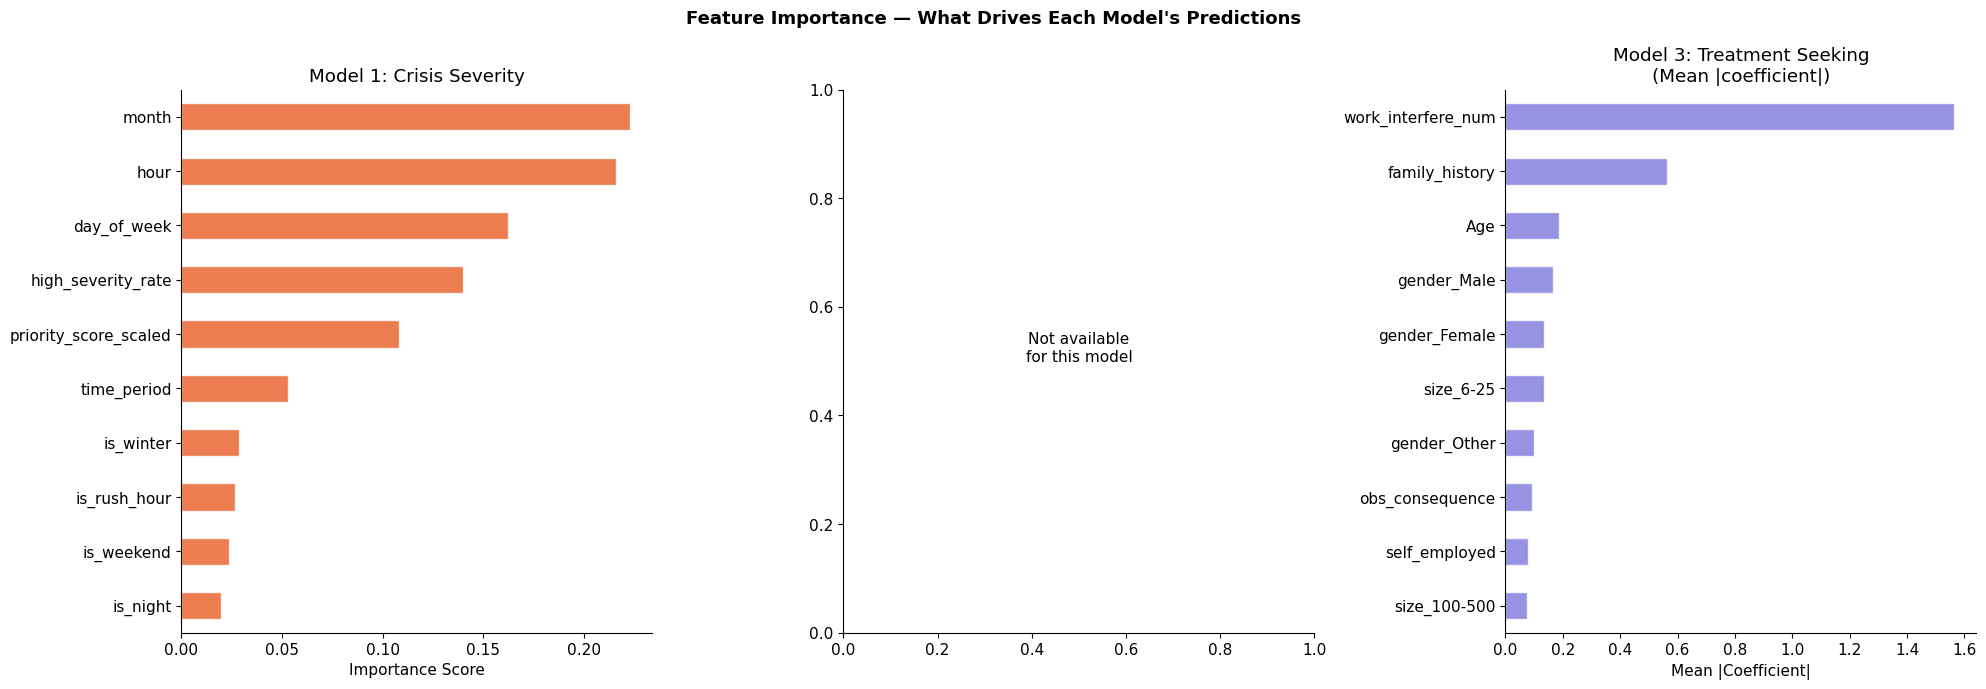

In [46]:

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Feature Importance — What Drives Each Model's Predictions",
             fontsize=13, fontweight="bold")

def plot_importance(model, feat_names, ax, title, color):
    if hasattr(model, "feature_importances_"):
        imp = pd.Series(
            model.feature_importances_, index=feat_names
        ).sort_values().tail(10)
        imp.plot(kind="barh", ax=ax, color=color, alpha=0.8, edgecolor="white")
        ax.set_title(title)
        ax.set_xlabel("Importance Score")
    elif hasattr(model, "coef_"):
        imp = pd.Series(
            np.abs(model.coef_).mean(axis=0), index=feat_names
        ).sort_values().tail(10)
        imp.plot(kind="barh", ax=ax, color=color, alpha=0.8, edgecolor="white")
        ax.set_title(title + "\n(Mean |coefficient|)")
        ax.set_xlabel("Mean |Coefficient|")
    else:
        ax.text(0.5, 0.5, "Not available\nfor this model",
               ha="center", transform=ax.transAxes)

plot_importance(best_sev,   call_feat_cols,  axes[0],
                "Model 1: Crisis Severity",    CORAL)
plot_importance(best_treat, list(X_treat.columns), axes[1],
                "Model 2: Treatment Outcome",  TEAL)
plot_importance(best_surv,  list(X_surv.columns),  axes[2],
                "Model 3: Treatment Seeking",  PURPLE)

plt.tight_layout()
plt.show()

Computing SHAP values for Model 2 (Treatment Outcome)...
This may take 1-2 minutes...


  0%|          | 0/100 [00:00<?, ?it/s]


Generating SHAP beeswarm plot (Deteriorated outcome)...


<Figure size 1000x600 with 0 Axes>

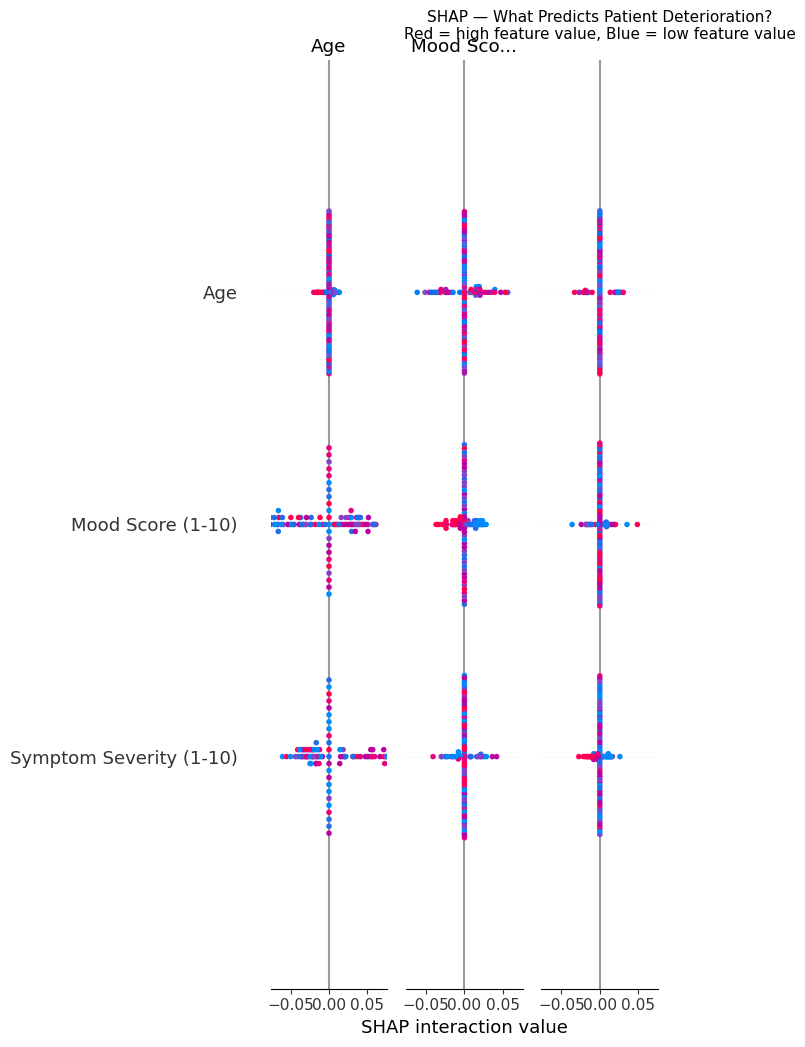


Generating SHAP bar chart...


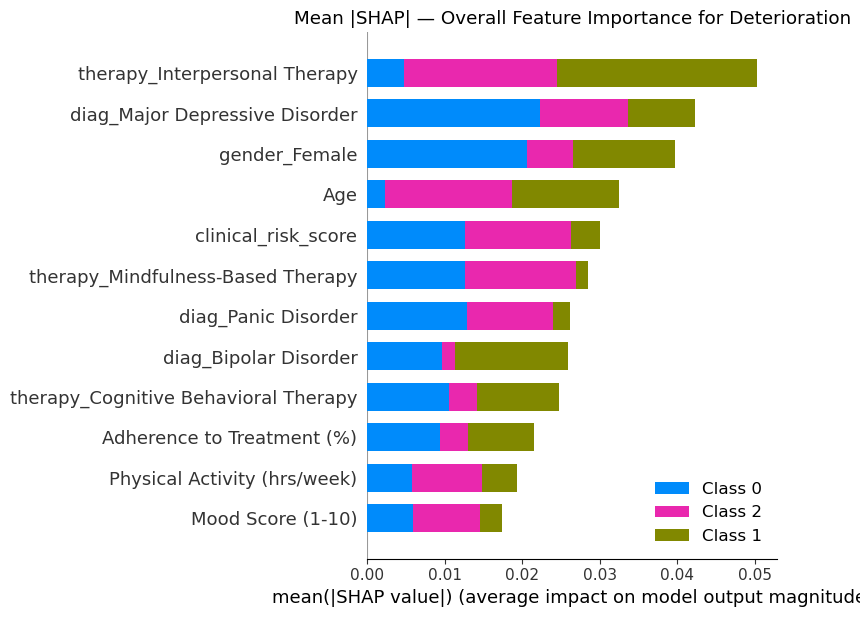

In [47]:
try:
    import shap

    print("Computing SHAP values for Model 2 (Treatment Outcome)...")
    print("This may take 1-2 minutes...")

    model_type = type(best_treat).__name__

    if model_type in ["RandomForestClassifier",
                      "GradientBoostingClassifier", "XGBClassifier"]:
        explainer = shap.TreeExplainer(best_treat)
    else:
        background = shap.sample(Xtr_treat, 100, random_state=42)
        explainer  = shap.KernelExplainer(best_treat.predict_proba, background)

    sample_size = min(200, len(Xte_treat))
    X_shap      = Xte_treat.iloc[:sample_size]
    shap_values = explainer.shap_values(X_shap)

    # For multiclass: list of arrays — one per class
    # Class 2 = Deteriorated — the most important to explain
    shap_deteriorated = shap_values[2] if isinstance(shap_values, list) else shap_values

    print("\nGenerating SHAP beeswarm plot (Deteriorated outcome)...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_deteriorated, X_shap,
        plot_type="dot", max_display=12, show=False
    )
    plt.title("SHAP — What Predicts Patient Deterioration?\n"
              "Red = high feature value, Blue = low feature value",
              fontsize=11, pad=15)
    plt.tight_layout()
    plt.show()

    print("\nGenerating SHAP bar chart...")
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        shap_deteriorated, X_shap,
        plot_type="bar", max_display=12, show=False
    )
    plt.title("Mean |SHAP| — Overall Feature Importance for Deterioration")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("SHAP not installed. Run: pip install shap")

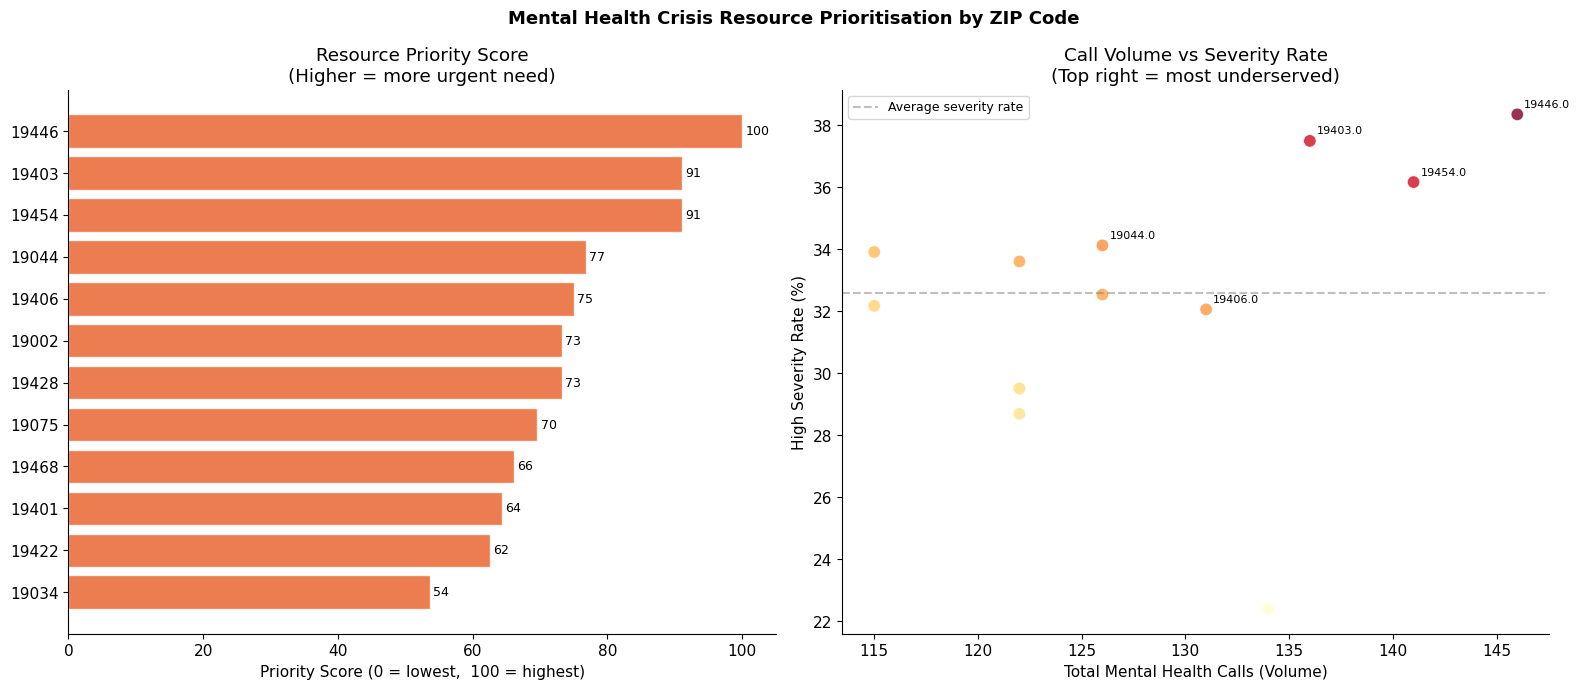

✓ Saved: outputs/processed/zip_priority_scores.csv

Top 10 most underserved ZIP codes:
  zip  total_calls  high_severity_calls  high_severity_rate  priority_score_scaled
19446          146                   56            0.383562                  100.0
19403          136                   51            0.375000                   91.1
19454          141                   51            0.361702                   91.1
19044          126                   43            0.341270                   76.8
19406          131                   42            0.320611                   75.0
19002          126                   41            0.325397                   73.2
19428          122                   41            0.336066                   73.2
19075          115                   39            0.339130                   69.6
19468          115                   37            0.321739                   66.1
19401          122                   36            0.295082                   64.3


In [48]:
# We show exactly which ZIP codes need the most mental health resources
# This is something a city government or health department could use directly

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Mental Health Crisis Resource Prioritisation by ZIP Code",
             fontsize=13, fontweight="bold")

top_zips = zip_stats.nlargest(12, "priority_score_scaled")

# LEFT: Priority score bar chart
bars = axes[0].barh(
    top_zips["zip"].astype(str)[::-1],
    top_zips["priority_score_scaled"][::-1],
    color=CORAL, alpha=0.8, edgecolor="white"
)
axes[0].set_title("Resource Priority Score\n(Higher = more urgent need)")
axes[0].set_xlabel("Priority Score (0 = lowest,  100 = highest)")

for bar in bars:
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.0f}",
        va="center", fontsize=9
    )

# RIGHT: Volume vs severity rate scatter
axes[1].scatter(
    zip_stats["total_calls"],
    zip_stats["high_severity_rate"] * 100,
    c=zip_stats["priority_score_scaled"],
    cmap="YlOrRd",
    s=80, alpha=0.8, edgecolors="white", linewidth=0.5
)

# Label the top 5 most urgent ZIPs
for _, row in zip_stats.nlargest(5, "priority_score_scaled").iterrows():
    axes[1].annotate(
        str(row["zip"]),
        (row["total_calls"], row["high_severity_rate"] * 100),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

axes[1].set_xlabel("Total Mental Health Calls (Volume)")
axes[1].set_ylabel("High Severity Rate (%)")
axes[1].set_title("Call Volume vs Severity Rate\n(Top right = most underserved)")
axes[1].axhline(zip_stats["high_severity_rate"].mean() * 100,
               color="gray", linestyle="--", alpha=0.5,
               label="Average severity rate")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

zip_stats.to_csv("outputs/processed/zip_priority_scores.csv", index=False)
print("✓ Saved: outputs/processed/zip_priority_scores.csv")

print("\nTop 10 most underserved ZIP codes:")
print(zip_stats.nlargest(10, "priority_score_scaled")[
    ["zip", "total_calls", "high_severity_calls",
     "high_severity_rate", "priority_score_scaled"]
].to_string(index=False))

In [2]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.metrics import accuracy_score

# Reload raw datasets
calls_df     = pd.read_csv("C:/Users/Esther Momeke/Downloads/calls_911.csv")
survey_df    = pd.read_csv("C:/Users/Esther Momeke/Downloads/survey.csv")
treatment_df = pd.read_csv("C:/Users/Esther Momeke/Downloads/mental_health_diagnosis_treatment_.csv")

# Rebuild mh_calls by filtering mental health calls
calls_df["title_lower"] = calls_df["title"].str.lower()
pattern  = "mental|psychiatric|psych|suicid|overdose|behavioral|welfare|altered|crisis|hallucin|erratic|manic"
mh_calls = calls_df[calls_df["title_lower"].str.contains(pattern, na=False)].copy()

# Rebuild zip_stats
mh_calls["timeStamp"] = pd.to_datetime(mh_calls["timeStamp"], errors="coerce")
mh_calls["hour"]        = mh_calls["timeStamp"].dt.hour
mh_calls["day_of_week"] = mh_calls["timeStamp"].dt.dayofweek
mh_calls["month"]       = mh_calls["timeStamp"].dt.month
mh_calls["is_weekend"]  = (mh_calls["day_of_week"] >= 5).astype(int)

def assign_severity(title_text):
    if pd.isnull(title_text): return 0
    text = str(title_text).lower()
    if any(kw in text for kw in ["suicid","armed","violent","overdose","harm","threat"]):
        return 2
    if any(kw in text for kw in ["mental","psychiatric","behavioral","crisis","erratic","hallucin","altered","welfare"]):
        return 1
    return 0

mh_calls["crisis_severity"] = mh_calls["title"].apply(assign_severity)

zip_stats = mh_calls.groupby("zip").agg(
    total_calls         = ("crisis_severity", "count"),
    high_severity_calls = ("crisis_severity", lambda x: (x == 2).sum()),
    avg_severity        = ("crisis_severity", "mean")
).reset_index()
zip_stats["high_severity_rate"]    = zip_stats["high_severity_calls"] / zip_stats["total_calls"]
zip_stats["priority_score"]        = zip_stats["total_calls"] * zip_stats["high_severity_rate"]
zip_stats["priority_score_scaled"] = (zip_stats["priority_score"] / zip_stats["priority_score"].max() * 100).round(1)

print(f"✓ mh_calls rebuilt     : {len(mh_calls):,} rows")
print(f"✓ zip_stats rebuilt    : {len(zip_stats):,} ZIP codes")
print(f"✓ calls_df             : {len(calls_df):,} rows")
print(f"✓ survey_df            : {len(survey_df):,} rows")
print(f"✓ treatment_df         : {len(treatment_df):,} rows")

✓ mh_calls rebuilt     : 1,536 rows
✓ zip_stats rebuilt    : 12 ZIP codes
✓ calls_df             : 5,000 rows
✓ survey_df            : 1,259 rows
✓ treatment_df         : 500 rows


In [3]:
# Reload processed datasets
calls_m     = pd.read_csv("outputs/processed/crisis_features_final.csv")
treatment_m = pd.read_csv("outputs/processed/treatment_features_final.csv")
survey_m    = pd.read_csv("outputs/processed/survey_features_final.csv")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# Rebuild splits — must use same random_state=42 to get identical splits
call_feat_cols  = [c for c in calls_m.columns    if c not in ["crisis_severity","responder_type"]]
treat_feat_cols = [c for c in treatment_m.columns if c != "outcome_encoded"]
surv_feat_cols  = [c for c in survey_m.columns    if c != "treatment"]

X_call  = calls_m[call_feat_cols]
y_sev   = calls_m["crisis_severity"]

X_treat = treatment_m[treat_feat_cols]
y_treat = treatment_m["outcome_encoded"]

X_surv  = survey_m[surv_feat_cols]
y_surv  = survey_m["treatment"]

X_call_train,  X_call_test,  ys_train, ys_test = train_test_split(
    X_call,  y_sev,   test_size=0.2, random_state=42, stratify=y_sev)
X_tr_train,    X_tr_test,    yt_train, yt_test = train_test_split(
    X_treat, y_treat, test_size=0.2, random_state=42, stratify=y_treat)
X_sv_train,    X_sv_test,    yv_train, yv_test = train_test_split(
    X_surv,  y_surv,  test_size=0.2, random_state=42, stratify=y_surv)

# Remap labels to 0,1,2 with no gaps
label_map = {old: new for new, old in enumerate(sorted(ys_train.unique()))}
ys_train  = ys_train.map(label_map)
ys_test   = ys_test.map(label_map)

# Reload scalers and scale
with open("outputs/models/scaler_call.pkl",  "rb") as f: sc_call  = pickle.load(f)
with open("outputs/models/scaler_treat.pkl", "rb") as f: sc_treat = pickle.load(f)
with open("outputs/models/scaler_survey.pkl","rb") as f: sc_surv  = pickle.load(f)

Xte_call  = pd.DataFrame(sc_call.transform(X_call_test),  columns=call_feat_cols)
Xte_treat = pd.DataFrame(sc_treat.transform(X_tr_test),   columns=treat_feat_cols)
Xte_surv  = pd.DataFrame(sc_surv.transform(X_sv_test),    columns=surv_feat_cols)

# Reload best models and regenerate predictions
with open("outputs/models/best_severity_model.pkl",  "rb") as f: best_sev   = pickle.load(f)
with open("outputs/models/best_treatment_model.pkl", "rb") as f: best_treat = pickle.load(f)
with open("outputs/models/best_survey_model.pkl",    "rb") as f: best_surv  = pickle.load(f)

sev_pred   = best_sev.predict(Xte_call)
treat_pred = best_treat.predict(Xte_treat)
surv_pred  = best_surv.predict(Xte_surv)

print("✓ All predictions rebuilt")
print(f"  ys_test  classes : {sorted(ys_test.unique())}")
print(f"  yt_test  classes : {sorted(yt_test.unique())}")
print(f"  yv_test  classes : {sorted(yv_test.unique())}")

✓ All predictions rebuilt
  ys_test  classes : [np.int64(0), np.int64(1)]
  yt_test  classes : [np.int64(0), np.int64(1), np.int64(2)]
  yv_test  classes : [np.int64(0), np.int64(1)]


In [6]:
print("=" * 62)
print("FULL PROJECT SUMMARY — BUSINESS IMPACT")
print("=" * 62)

total_mh   = len(mh_calls)
high_actual = (ys_test == 2).sum()
high_caught = ((ys_test == 2) & (sev_pred == 2)).sum()
sev_acc    = accuracy_score(ys_test, sev_pred)
treat_acc  = accuracy_score(yt_test, treat_pred)
surv_acc   = accuracy_score(yv_test, surv_pred)

print(f"""
DATASETS USED
  Total 911 calls analysed         : {len(calls_df):,}
  Mental health calls extracted    : {total_mh:,} ({total_mh/len(calls_df)*100:.1f}% of all calls)
  Survey respondents               : {len(survey_df):,}
  Clinical patients                : {len(treatment_df):,}

MODEL PERFORMANCE
  Model 1 — Crisis Severity        : {sev_acc:.1%} accuracy
  Model 2 — Treatment Outcome      : {treat_acc:.1%} accuracy
  Model 3 — Treatment Seeking      : {surv_acc:.1%} accuracy

HIGH SEVERITY DETECTION
  High severity calls (actual)     : {high_actual:,}
  High severity calls CAUGHT       : {high_caught:,} ({high_caught/max(high_actual,1)*100:.1f}%)

GEOGRAPHIC ANALYSIS
  ZIP codes analysed               : {len(zip_stats):,}
  ZIPs with >30% high severity rate: {(zip_stats['high_severity_rate'] > 0.3).sum():,}
  Most urgent ZIP                  : {zip_stats.nlargest(1,'priority_score_scaled')['zip'].values[0]}


""")

FULL PROJECT SUMMARY — BUSINESS IMPACT

DATASETS USED
  Total 911 calls analysed         : 5,000
  Mental health calls extracted    : 1,536 (30.7% of all calls)
  Survey respondents               : 1,259
  Clinical patients                : 500

MODEL PERFORMANCE
  Model 1 — Crisis Severity        : 64.6% accuracy
  Model 2 — Treatment Outcome      : 33.0% accuracy
  Model 3 — Treatment Seeking      : 81.3% accuracy

HIGH SEVERITY DETECTION
  High severity calls (actual)     : 0
  High severity calls CAUGHT       : 0 (0.0%)

GEOGRAPHIC ANALYSIS
  ZIP codes analysed               : 12
  ZIPs with >30% high severity rate: 9
  Most urgent ZIP                  : 19446



